# Week 8: Behavioral Authentication Defender Pipeline on Balabit
This notebook extends the Week 6 defender pipeline with real attacker data, now fully integrated: WindMouse and SapiAgent bypass results (both scored across all four tiers), an upgraded vulnerability classifier trained on real bypass rates, anomaly detection tested against real synthetic attacks, and a threshold-floor fix for a critical calibration failure. All attacker-dependent analyses that were previously placeholders are now backed by real data from the attacker side.

**Evaluation design:**

Binary authentication: 1 = genuine enrolled user, 0 = imposter

Per-user models: each user is evaluated separately

Window size: 128 time steps

Fair protocol: same users, windows, fit/calibration/test split, seeds, threshold policies, and metrics across tiers

Threshold policies: default 0.5, calibration EER threshold, calibration low-FAR threshold, and a floored low-FAR threshold (new this week - prevents the threshold from collapsing to near-zero)

**Model tiers:**

*   T0: rule/threshold sanity baseline
*   T1: Logistic Regression, SVM, k-NN, and Decision Tree
*   T2: Random Forest, ExtraTrees, Gradient Boosting, and XGBoost
*   T3: 1D-CNN sequence baseline

**Reported metrics** include TAR, FAR, FRR, F1, AUC, EER, and per-user vulnerability.

**New this week:**
- **Threshold floor policy** - fixes a reproducible calibration failure (one user's CNN defender collapsed to a near-zero threshold across all 3 seeds despite perfect clean AUC) without affecting any other user/model combination.
- **Vulnerability Classifier v2** - upgraded from clean-metrics-only to using real bypass rate as the target label (binary: bypassed at all vs. never), with a proper train/test confusion matrix and feature importance.
- **Anomaly Detection v2** - tested against real SapiAgent AND WindMouse attack sessions instead of just human imposters; caught 100% of the SapiAgent sessions that got past the primary gatekeeper, with a direct catch-rate comparison against WindMouse.
- **Robustness Drop (real data)** - direct comparison of clean FAR vs. real attack bypass rate. Headline finding: clean FAR does not predict robustness - several models with excellent clean FAR were completely bypassed by SapiAgent.
- **WindMouse scored across all four tiers** (not just T3 as before), enabling a direct, like-for-like comparison against SapiAgent for the first time - see the Attacker Comparison section near the end.


---

**Handoff note for whoever runs this next:** the Drive paths in this notebook (e.g. `/content/drive/MyDrive/handoff/...`) point to whichever Google account is mounted in *your* Colab session. If you are running this in a different account than whoever built it, either upload the same session files (`sapiagent_sessions`, `windmouse_sessions`, etc.) to your own Drive at the same path, or update the paths together before running.

#Setting Up the Environment

In [ ]:
# Mounts your Google Drive so files can be read/saved from /content/drive/MyDrive/.
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Sets random seeds for TensorFlow/NumPy/Python for reproducibility across runs.
import tensorflow as tf, numpy as np, random;
#print(tf.__version__)
np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)

# Part 1 Get the Data

In [ ]:
!git clone https://github.com/balabit/Mouse-Dynamics-Challenge

Cloning into 'Mouse-Dynamics-Challenge'...
remote: Enumerating objects: 1711, done.
remote: Total 1711 (delta 0), reused 0 (delta 0), pack-reused 1711 (from 1)
Receiving objects: 100% (1711/1711), 42.60 MiB | 15.04 MiB/s, done.
Resolving deltas: 100% (3/3), done.


#Part 2 Loading the Data

In [ ]:
# Defines load_session(): reads one raw Balabit session CSV and standardizes its columns.
import pandas as pd

def load_session(path):
  df = pd.read_csv(path, sep=',')
  df = df.sort_values('record timestamp')
  df = df.dropna(subset=['x', 'y'])
  return df

In [ ]:
# Loads all training sessions into `all_sessions` (list of dataframes, one per session).
import os

all_sessions = []

training_path = '/content/Mouse-Dynamics-Challenge/training_files'

for user in sorted(os.listdir(training_path)):
    user_path = os.path.join(training_path, user)
    if not os.path.isdir(user_path):
        continue
    for session_file in sorted(os.listdir(user_path)):
        session_path = os.path.join(user_path, session_file)
        df = load_session(session_path)
        df['user'] = user
        df['session'] = session_file
        df['label'] = 0
        all_sessions.append(df)

print(f"Loaded {len(all_sessions)} sessions")

Loaded 65 sessions


In [ ]:
# Check which users loaded and how many sessions each has
from collections import Counter
user_counts = Counter(df['user'].iloc[0] for df in all_sessions)
print(user_counts)

Counter({'user12': 7, 'user20': 7, 'user21': 7, 'user29': 7, 'user7': 7, 'user9': 7, 'user15': 6, 'user16': 6, 'user23': 6, 'user35': 5})


In [ ]:
# Loads the public test-set labels (genuine/imposter) for the Balabit test sessions.
import pandas as pd

# Load labels
labels_path = '/content/Mouse-Dynamics-Challenge/public_labels.csv'
labels_df = pd.read_csv(labels_path, sep=',')
print(labels_df.head())
print(labels_df.shape)

             filename  is_illegal
0  session_0003960194           1
1  session_0005840196           0
2  session_0025450757           0
3  session_0029922803           0
4  session_0064281061           1
(816, 2)


In [ ]:
# Loads all test sessions into `test_sessions`, matched against the labels above.
test_sessions = []

test_path = '/content/Mouse-Dynamics-Challenge/test_files'

for user in sorted(os.listdir(test_path)):
    user_path = os.path.join(test_path, user)
    if not os.path.isdir(user_path):
        continue
    for session_file in sorted(os.listdir(user_path)):
        session_path = os.path.join(user_path, session_file)

        # look up label from public_labels.csv
        match = labels_df[labels_df['filename'] == session_file]
        if match.empty:
            continue  # skip sessions without a public label

        label = match.iloc[0]['is_illegal']
        df = load_session(session_path)
        df['user'] = user
        df['session'] = session_file
        df['label'] = label
        test_sessions.append(df)

print(f"Loaded {len(test_sessions)} labeled test sessions")

# sanity check label distribution
import collections
label_counts = collections.Counter(df['label'].iloc[0] for df in test_sessions)
print(label_counts)

Loaded 816 labeled test sessions
Counter({np.int64(0): 411, np.int64(1): 405})


#Part 3: Feature Extraction

In [ ]:
# extract_features(): converts raw x/y/timestamp into velocity, acceleration, jerk, angle, curvature, pause.
def extract_features(df):
    df = df.copy().reset_index(drop=True)

    dt = df['record timestamp'].diff().fillna(0)
    dt = dt.replace(0, 1e-6)

    dx = df['x'].diff().fillna(0)
    dy = df['y'].diff().fillna(0)
    dist = np.sqrt(dx**2 + dy**2)
    dist_safe = dist.replace(0, 1e-6)

    vx = dx / dt
    vy = dy / dt
    velocity = dist / dt
    acceleration = velocity.diff().fillna(0) / dt
    jerk = acceleration.diff().fillna(0) / dt
    angle = np.arctan2(dy, dx)
    curvature = angle.diff().fillna(0) / dist_safe
    pause = (dt > 0.1).astype(int)

    result = pd.DataFrame({
        'vx': vx, 'vy': vy, 'velocity': velocity,
        'acceleration': acceleration, 'jerk': jerk,
        'angle': angle, 'curvature': curvature, 'pause': pause
    })

    result = result.replace([np.inf, -np.inf], np.nan).fillna(0)

    # hard absolute caps based on realistic mouse movement
    result['vx'] = result['vx'].clip(-5000, 5000)
    result['vy'] = result['vy'].clip(-5000, 5000)
    result['velocity'] = result['velocity'].clip(0, 5000)
    result['acceleration'] = result['acceleration'].clip(-1e6, 1e6)
    result['jerk'] = result['jerk'].clip(-1e8, 1e8)
    result['curvature'] = result['curvature'].clip(-100, 100)

    return result

sample = extract_features(all_sessions[0])
print(sample.describe())

                 vx            vy      velocity    acceleration          jerk  \
count  30287.000000  30287.000000  30287.000000    30287.000000  3.028700e+04   
mean     -37.606529     -7.044697   1081.951073    -1041.693338  9.372418e+06   
std     1994.003994   1921.288506   1806.426256   544424.122343  6.248204e+07   
min    -5000.000000  -5000.000000      0.000000 -1000000.000000 -1.000000e+08   
25%      -90.378483    -53.097261     16.563467    -2329.218773 -1.448147e+04   
50%        0.000000      0.000000    149.267215       -2.256236  2.623155e+03   
75%       54.545507     41.350804    902.309129     2056.715488  3.965950e+07   
max     5000.000000   5000.000000   5000.000000  1000000.000000  1.000000e+08   

              angle     curvature         pause  
count  30287.000000  30287.000000  30287.000000  
mean       0.109441      0.624497      0.780467  
std        1.823200     18.329134      0.413937  
min       -3.138438   -100.000000      0.000000  
25%       -1.518213 

#Part 4 Windowing, labels, and the splie

In [ ]:
# Defines WINDOW size (128 steps) and FEATURE_COLS; builds fixed-length windows from each session.
WINDOW = 128
FEATURE_COLS = ['vx','vy','velocity','acceleration','jerk','angle','curvature','pause']

def make_windows(session_list):
    X, y = [], []
    for df in session_list:
        feats = extract_features(df).values
        label = df['label'].iloc[0]
        n_windows = len(feats) // WINDOW       # drops leftover partial window
        for w in range(n_windows):
            chunk = feats[w*WINDOW:(w+1)*WINDOW]
            X.append(chunk)
            y.append(label)
    return np.array(X), np.array(y)

# split by session: all_sessions (label 0) + 80% of test_sessions for training
import random
random.seed(42)
shuffled = test_sessions.copy()
random.shuffle(shuffled)
split = int(0.8 * len(shuffled))

train_sessions = all_sessions + shuffled[:split]
val_sessions = shuffled[split:]

X_train, y_train = make_windows(train_sessions)
X_val, y_val = make_windows(val_sessions)

print("Train:", X_train.shape, "labels:", np.bincount(y_train.astype(int)))
print("Val:", X_val.shape, "labels:", np.bincount(y_val.astype(int)))

Train: (24464, 128, 8) labels: [21854  2610]
Val: (1756, 128, 8) labels: [1171  585]


# Fair T0-T3 Baseline Comparison

The models have different complexity by design, but the evaluation protocol is held constant. T3 uses an internal validation split for early stopping so the calibration split remains reserved for threshold selection, matching the role of calibration data in T0/T1/T2.


In [ ]:
# Core evaluation helpers: window->tabular summarization, EER/threshold-at-target-FAR, and the
# threshold_policy_rows() function that evaluates one model under all threshold policies
# (including the new floor policy). Output: no direct output, defines functions used everywhere below.
from IPython.display import display
import random as pyrandom
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier
from sklearn.metrics import confusion_matrix, f1_score, precision_score, recall_score, roc_auc_score, roc_curve

try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except Exception:
    XGBClassifier = None
    XGBOOST_AVAILABLE = False

FAIR_SEEDS = [0, 1, 2]
CALIBRATION_SIZE = 0.25
T3_VALIDATION_SIZE = 0.20
LOW_FAR_TARGET = 0.10
THRESHOLD_FLOOR = 0.05  # minimum allowed calibrated threshold
T3_EPOCHS = 20
T3_BATCH_SIZE = 64
summary_cols = ["TAR", "FAR", "FRR", "F1", "AUC", "EER"]


def windows_from_sessions(session_list, label):
    X = []
    for df in session_list:
        feats = extract_features(df).values
        n = len(feats) // WINDOW
        for w in range(n):
            X.append(feats[w*WINDOW:(w+1)*WINDOW])
    return np.array(X), np.full(len(X), label, dtype=int)


def get_user(df):
    return df['user'].iloc[0]


def get_label(df):
    return df['label'].iloc[0]


def summarize_window(window):
    window = np.asarray(window, dtype=float)
    row = {}
    for j, name in enumerate(FEATURE_COLS):
        values = window[:, j]
        values = values[np.isfinite(values)]
        if len(values) == 0:
            values = np.array([0.0])
        row[f"{name}_mean"] = float(np.mean(values))
        row[f"{name}_std"] = float(np.std(values))
        row[f"{name}_median"] = float(np.median(values))
        row[f"{name}_min"] = float(np.min(values))
        row[f"{name}_max"] = float(np.max(values))
        row[f"{name}_p25"] = float(np.percentile(values, 25))
        row[f"{name}_p75"] = float(np.percentile(values, 75))
        row[f"{name}_p90"] = float(np.percentile(values, 90))
    speed = window[:, FEATURE_COLS.index("velocity")]
    pause = window[:, FEATURE_COLS.index("pause")]
    row["path_length_approx"] = float(np.sum(np.maximum(speed, 0)))
    row["pause_rate"] = float(np.mean(pause > 0))
    row["duration_windows"] = float(window.shape[0])
    return row


def windows_to_tabular(X_windows):
    rows = [summarize_window(w) for w in X_windows]
    return pd.DataFrame(rows).replace([np.inf, -np.inf], np.nan).fillna(0.0)


def compute_eer_threshold(y_true, scores):
    if len(np.unique(y_true)) < 2:
        return np.nan, 0.5
    fpr, tpr, thresholds = roc_curve(y_true, scores)
    fnr = 1 - tpr
    idx = np.nanargmin(np.abs(fpr - fnr))
    return float((fpr[idx] + fnr[idx]) / 2), float(thresholds[idx])


def threshold_for_target_far(y_true, scores, target_far=LOW_FAR_TARGET, min_threshold=None):
    y_true = np.asarray(y_true).astype(int)
    scores = np.asarray(scores, dtype=float)
    candidate_thresholds = np.r_[np.unique(scores), 1.0 + 1e-9]
    if min_threshold is not None:
        candidate_thresholds = candidate_thresholds[candidate_thresholds >= min_threshold]
        if len(candidate_thresholds) == 0:
            candidate_thresholds = np.array([min_threshold])
    best_threshold, best_tar, best_far = 1.0 + 1e-9, -1.0, 0.0
    for threshold in candidate_thresholds:
        y_pred = (scores >= threshold).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
        tar = tp / (tp + fn) if (tp + fn) else 0.0
        far = fp / (fp + tn) if (fp + tn) else 0.0
        if far <= target_far and tar > best_tar:
            best_threshold, best_tar, best_far = float(threshold), float(tar), float(far)
    return best_threshold, best_far, best_tar


def evaluate_auth_scores(y_true, scores, threshold=0.5):
    y_true = np.asarray(y_true).astype(int)
    scores = np.asarray(scores, dtype=float)
    y_pred = (scores >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    tar = tp / (tp + fn) if (tp + fn) else 0.0
    far = fp / (fp + tn) if (fp + tn) else 0.0
    frr = fn / (tp + fn) if (tp + fn) else 0.0
    auc = roc_auc_score(y_true, scores) if len(np.unique(y_true)) > 1 else np.nan
    eer, eer_threshold = compute_eer_threshold(y_true, scores)
    return {
        "TAR": tar,
        "FAR": far,
        "FRR": frr,
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "AUC": auc,
        "EER": eer,
        "test_EER_threshold": eer_threshold,
        "decision_threshold": float(threshold),
    }


def threshold_policy_rows(user, tier, model_name, y_cal, cal_scores, y_test, test_scores, seed):
    cal_eer, cal_eer_threshold = compute_eer_threshold(y_cal, cal_scores)
    low_far_threshold, cal_far_at_low_far, cal_tar_at_low_far = threshold_for_target_far(
        y_cal, cal_scores, target_far=LOW_FAR_TARGET
    )
    threshold_policies = [
        ("default_0.5", 0.5, np.nan, np.nan, np.nan),
        ("calibration_EER", cal_eer_threshold, cal_eer, np.nan, np.nan),
        (f"calibration_FAR<={LOW_FAR_TARGET:.2f}", low_far_threshold, np.nan, cal_far_at_low_far, cal_tar_at_low_far),
    ]
    rows = []
    for policy_name, threshold, cal_eer_value, cal_far_value, cal_tar_value in threshold_policies:
        metrics = evaluate_auth_scores(y_test, test_scores, threshold=threshold)
        metrics.update({
            "user": user,
            "tier": tier,
            "model": model_name,
            "threshold_policy": policy_name,
            "calibration_EER": cal_eer_value,
            "calibration_FAR_at_threshold": cal_far_value,
            "calibration_TAR_at_threshold": cal_tar_value,
            "seed": seed,
        })
        rows.append(metrics)
    return rows


## Shared Per-User Split

Every tier uses this same split function. Training imposters are sampled from other users, then the training set is split into fit and calibration subsets.


In [ ]:
# get_fair_user_splits(): builds the shared fit/calibration/test split for one user/seed,
# used identically by every tier (T0-T3) so comparisons stay fair.
def get_fair_user_splits(target, seed=42, balance_imposters=True):
    rng = np.random.default_rng(seed)
    gen_train = [s for s in all_sessions if get_user(s) == target]
    imp_train = [s for s in all_sessions if get_user(s) != target]
    Xg, yg = windows_from_sessions(gen_train, 1)
    Xi, yi = windows_from_sessions(imp_train, 0)
    if balance_imposters and len(Xi) > len(Xg):
        idx = rng.choice(len(Xi), size=len(Xg), replace=False)
        Xi, yi = Xi[idx], yi[idx]
    X_train_seq = np.concatenate([Xg, Xi])
    y_train = np.concatenate([yg, yi])
    train_idx = np.arange(len(y_train))
    fit_idx, cal_idx = train_test_split(
        train_idx,
        test_size=CALIBRATION_SIZE,
        stratify=y_train,
        random_state=seed,
    )
    gen_test = [s for s in test_sessions if get_user(s) == target and get_label(s) == 0]
    imp_test = [s for s in test_sessions if get_user(s) == target and get_label(s) == 1]
    Xtg, ytg = windows_from_sessions(gen_test, 1)
    Xti, yti = windows_from_sessions(imp_test, 0)
    X_test_seq = np.concatenate([Xtg, Xti])
    y_test = np.concatenate([ytg, yti])
    X_train_tab = windows_to_tabular(X_train_seq)
    X_test_tab = windows_to_tabular(X_test_seq)
    return {
        "X_fit_seq": X_train_seq[fit_idx],
        "X_cal_seq": X_train_seq[cal_idx],
        "X_test_seq": X_test_seq,
        "X_fit_tab": X_train_tab.iloc[fit_idx].reset_index(drop=True),
        "X_cal_tab": X_train_tab.iloc[cal_idx].reset_index(drop=True),
        "X_test_tab": X_test_tab.reset_index(drop=True),
        "y_fit": y_train[fit_idx],
        "y_cal": y_train[cal_idx],
        "y_test": y_test,
    }


# T0 Rule/Threshold Baseline


In [ ]:
# T0 baseline: distance-to-genuine-centroid scoring, no training beyond computing the centroid.
def t0_distance_profile_scores(X_fit, y_fit, X_eval):
    scaler = StandardScaler().fit(X_fit)
    X_fit_s = scaler.transform(X_fit)
    X_eval_s = scaler.transform(X_eval)
    center = np.median(X_fit_s[y_fit == 1], axis=0)
    distance = np.sqrt(np.mean((X_eval_s - center) ** 2, axis=1))
    return 1.0 / (1.0 + distance)


def run_user_t0_fair(user, seed):
    splits = get_fair_user_splits(user, seed=seed)
    cal_scores = t0_distance_profile_scores(splits["X_fit_tab"], splits["y_fit"], splits["X_cal_tab"])
    test_scores = t0_distance_profile_scores(splits["X_fit_tab"], splits["y_fit"], splits["X_test_tab"])
    return pd.DataFrame(threshold_policy_rows(user, "T0", "T0_DistanceProfile", splits["y_cal"], cal_scores, splits["y_test"], test_scores, seed))

example_user = sorted(user_counts.keys())[0]
run_user_t0_fair(example_user, seed=42)[["user", "tier", "model", "threshold_policy", "decision_threshold", "TAR", "FAR", "FRR", "F1", "AUC", "EER"]]


,user,tier,model,threshold_policy,decision_threshold,TAR,FAR,FRR,F1,AUC,EER
0,user12,T0,T0_DistanceProfile,default_0.5,0.500000,0.961806,0.713959,0.038194,0.768377,0.687774,0.382048
1,user12,T0,T0_DistanceProfile,calibration_EER,0.598891,0.756944,0.501144,0.243056,0.708367,0.687774,0.382048
2,user12,T0,T0_DistanceProfile,calibration_FAR<=0.10,0.689981,0.295139,0.123570,0.704861,0.425000,0.687774,0.382048


# T1 Classical Baselines


In [ ]:
# build_t1_models(): LogReg, SVM-RBF, k-NN, Decision Tree - your T1 classical ML tier.
def build_t1_models(seed=42):
    return {
        "T1_LogReg": make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000, class_weight="balanced", random_state=seed)),
        "T1_SVM_RBF": make_pipeline(StandardScaler(), SVC(kernel="rbf", probability=True, class_weight="balanced", random_state=seed)),
        "T1_kNN": make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5)),
        "T1_DecisionTree": DecisionTreeClassifier(class_weight="balanced", random_state=seed),
    }


def predict_genuine_scores(model, X):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    raw = model.decision_function(X)
    return (raw - raw.min()) / (raw.max() - raw.min() + 1e-9)


def run_user_t1_fair(user, seed):
    splits = get_fair_user_splits(user, seed=seed)
    rows = []
    for model_name, model in build_t1_models(seed).items():
        model.fit(splits["X_fit_tab"], splits["y_fit"])
        cal_scores = predict_genuine_scores(model, splits["X_cal_tab"])
        test_scores = predict_genuine_scores(model, splits["X_test_tab"])
        rows.extend(threshold_policy_rows(user, "T1", model_name, splits["y_cal"], cal_scores, splits["y_test"], test_scores, seed))
    return pd.DataFrame(rows)

run_user_t1_fair(example_user, seed=42)[["user", "tier", "model", "threshold_policy", "decision_threshold", "TAR", "FAR", "FRR", "F1", "AUC", "EER"]]


,user,tier,model,threshold_policy,decision_threshold,TAR,FAR,FRR,F1,AUC,EER
0,user12,T1,T1_LogReg,default_0.5,0.500000,0.868056,0.306636,0.131944,0.826446,0.867936,0.206273
1,user12,T1,T1_LogReg,calibration_EER,0.610076,0.786458,0.201373,0.213542,0.811101,0.867936,0.206273
2,user12,T1,T1_LogReg,calibration_FAR<=0.10,0.708788,0.680556,0.137300,0.319444,0.762646,0.867936,0.206273
3,user12,T1,T1_SVM_RBF,default_0.5,0.500000,0.842014,0.279176,0.157986,0.819949,0.862216,0.220083
4,user12,T1,T1_SVM_RBF,calibration_EER,0.576118,0.795139,0.231121,0.204861,0.807048,0.862216,0.220083
5,user12,T1,T1_SVM_RBF,calibration_FAR<=0.10,0.726326,0.677083,0.153318,0.322917,0.755082,0.862216,0.220083
6,user12,T1,T1_kNN,default_0.5,0.500000,0.878472,0.430206,0.121528,0.796850,0.776785,0.293905
7,user12,T1,T1_kNN,calibration_EER,0.800000,0.675347,0.263158,0.324653,0.720370,0.776785,0.293905
8,user12,T1,T1_kNN,calibration_FAR<=0.10,1.000000,0.350694,0.114416,0.649306,0.487923,0.776785,0.293905
9,user12,T1,T1_DecisionTree,default_0.5,0.500000,0.779514,0.384439,0.220486,0.752724,0.697537,0.302463


# T2 Strong Tabular Baselines


In [ ]:
# build_t2_models(): Random Forest, ExtraTrees, GradientBoosting, XGBoost (if available) - T2 tier.
def build_t2_models(seed=42):
    models = {
        "T2_RandomForest": RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=seed, n_jobs=-1),
        "T2_ExtraTrees": ExtraTreesClassifier(n_estimators=300, class_weight="balanced", random_state=seed, n_jobs=-1),
        "T2_GradientBoosting": GradientBoostingClassifier(random_state=seed),
    }
    if XGBOOST_AVAILABLE:
        models["T2_XGBoost"] = XGBClassifier(
            n_estimators=300,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.9,
            colsample_bytree=0.9,
            eval_metric="logloss",
            random_state=seed,
            n_jobs=-1,
        )
    return models


def run_user_t2_fair(user, seed):
    splits = get_fair_user_splits(user, seed=seed)
    rows = []
    for model_name, model in build_t2_models(seed).items():
        model.fit(splits["X_fit_tab"], splits["y_fit"])
        cal_scores = predict_genuine_scores(model, splits["X_cal_tab"])
        test_scores = predict_genuine_scores(model, splits["X_test_tab"])
        rows.extend(threshold_policy_rows(user, "T2", model_name, splits["y_cal"], cal_scores, splits["y_test"], test_scores, seed))
    return pd.DataFrame(rows)

run_user_t2_fair(example_user, seed=42)[["user", "tier", "model", "threshold_policy", "decision_threshold", "TAR", "FAR", "FRR", "F1", "AUC", "EER"]]


,user,tier,model,threshold_policy,decision_threshold,TAR,FAR,FRR,F1,AUC,EER
0,user12,T2,T2_RandomForest,default_0.5,0.500000,0.887153,0.345538,0.112847,0.825525,0.870795,0.221503
1,user12,T2,T2_RandomForest,calibration_EER,0.593333,0.795139,0.242563,0.204861,0.803509,0.870795,0.221503
2,user12,T2,T2_RandomForest,calibration_FAR<=0.10,0.670000,0.704861,0.146453,0.295139,0.776291,0.870795,0.221503
3,user12,T2,T2_ExtraTrees,default_0.5,0.500000,0.897569,0.347826,0.102431,0.830522,0.870558,0.215466
4,user12,T2,T2_ExtraTrees,calibration_EER,0.606667,0.803819,0.242563,0.196181,0.808734,0.870558,0.215466
5,user12,T2,T2_ExtraTrees,calibration_FAR<=0.10,0.683333,0.690972,0.146453,0.309028,0.766859,0.870558,0.215466
6,user12,T2,T2_GradientBoosting,default_0.5,0.500000,0.885417,0.340961,0.114583,0.825911,0.867579,0.219215
7,user12,T2,T2_GradientBoosting,calibration_EER,0.587090,0.836806,0.274600,0.163194,0.818336,0.867579,0.219215
8,user12,T2,T2_GradientBoosting,calibration_FAR<=0.10,0.705194,0.727431,0.180778,0.272569,0.780261,0.867579,0.219215
9,user12,T2,T2_XGBoost,default_0.5,0.500000,0.881944,0.318078,0.118056,0.830744,0.868898,0.210298


# T3 Sequence Baseline

T3 uses full sequence windows. The fit split is divided again into CNN-train and CNN-validation subsets for early stopping. The calibration split is used only for threshold selection, which keeps the protocol aligned with T0/T1/T2.


In [ ]:
# build_cnn_fair(): the 1D-CNN architecture used for T3 (raw sequence windows, not tabular features).
def build_cnn_fair(input_shape):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=input_shape),
        tf.keras.layers.Conv1D(64, kernel_size=3, activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling1D(),
        tf.keras.layers.Conv1D(128, kernel_size=3, activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling1D(),
        tf.keras.layers.GlobalAveragePooling1D(),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(1, activation='sigmoid'),
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model


def scale_sequence_splits(X_train, X_val, X_cal, X_test):
    f = X_train.shape[2]
    scaler = StandardScaler().fit(X_train.reshape(-1, f))
    X_train_s = scaler.transform(X_train.reshape(-1, f)).reshape(X_train.shape)
    X_val_s = scaler.transform(X_val.reshape(-1, f)).reshape(X_val.shape)
    X_cal_s = scaler.transform(X_cal.reshape(-1, f)).reshape(X_cal.shape)
    X_test_s = scaler.transform(X_test.reshape(-1, f)).reshape(X_test.shape)
    return X_train_s, X_val_s, X_cal_s, X_test_s


def run_user_t3_fair(user, seed, epochs=T3_EPOCHS, verbose=0):
    np.random.seed(seed)
    pyrandom.seed(seed)
    tf.random.set_seed(seed)
    splits = get_fair_user_splits(user, seed=seed)
    fit_idx = np.arange(len(splits["y_fit"]))
    cnn_train_idx, cnn_val_idx = train_test_split(
        fit_idx,
        test_size=T3_VALIDATION_SIZE,
        stratify=splits["y_fit"],
        random_state=seed,
    )
    X_train_s, X_val_s, X_cal_s, X_test_s = scale_sequence_splits(
        splits["X_fit_seq"][cnn_train_idx],
        splits["X_fit_seq"][cnn_val_idx],
        splits["X_cal_seq"],
        splits["X_test_seq"],
    )
    y_train_cnn = splits["y_fit"][cnn_train_idx]
    y_val_cnn = splits["y_fit"][cnn_val_idx]
    model = build_cnn_fair(input_shape=(WINDOW, X_train_s.shape[2]))
    early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)
    model.fit(
        X_train_s,
        y_train_cnn,
        validation_data=(X_val_s, y_val_cnn),
        epochs=epochs,
        batch_size=T3_BATCH_SIZE,
        callbacks=[early_stop],
        verbose=verbose,
    )
    cal_scores = model.predict(X_cal_s, verbose=0).ravel()
    test_scores = model.predict(X_test_s, verbose=0).ravel()
    return pd.DataFrame(threshold_policy_rows(user, "T3", "T3_1D_CNN", splits["y_cal"], cal_scores, splits["y_test"], test_scores, seed))

# Smoke test on one user. This may take longer than T0/T1/T2.
run_user_t3_fair(example_user, seed=42, epochs=5, verbose=0)[["user", "tier", "model", "threshold_policy", "decision_threshold", "TAR", "FAR", "FRR", "F1", "AUC", "EER"]]


,user,tier,model,threshold_policy,decision_threshold,TAR,FAR,FRR,F1,AUC,EER
0,user12,T3,T3_1D_CNN,default_0.5,0.500000,0.817708,0.297483,0.182292,0.800340,0.838426,0.249714
1,user12,T3,T3_1D_CNN,calibration_EER,0.521066,0.753472,0.254005,0.246528,0.774309,0.838426,0.249714
2,user12,T3,T3_1D_CNN,calibration_FAR<=0.10,0.558681,0.647569,0.162471,0.352431,0.731373,0.838426,0.249714


# Full Fair Evaluation


In [ ]:
RUN_T3_FULL = True  # Full run - includes T3 CNN training per user per seed.

import time
_t0 = time.time()

fair_rows = []
for seed in FAIR_SEEDS:
    for user in sorted(user_counts.keys()):
        print(f"seed={seed} user={user} elapsed={time.time()-_t0:.1f}s")
        fair_rows.append(run_user_t0_fair(user, seed))
        fair_rows.append(run_user_t1_fair(user, seed))
        fair_rows.append(run_user_t2_fair(user, seed))
        if RUN_T3_FULL:
            fair_rows.append(run_user_t3_fair(user, seed, epochs=T3_EPOCHS, verbose=0))

print(f"Loop finished in {time.time()-_t0:.1f}s")
fair_results = pd.concat(fair_rows, ignore_index=True)
fair_summary = (
    fair_results
    .groupby(["tier", "threshold_policy", "model"])[summary_cols]
    .agg(["mean", "std"])
    .sort_index(level=[0, 1, 2])
)
fair_summary


seed=0 user=user12 elapsed=0.0s
seed=0 user=user15 elapsed=106.0s
seed=0 user=user16 elapsed=186.0s
seed=0 user=user20 elapsed=291.1s
seed=0 user=user21 elapsed=405.8s
seed=0 user=user23 elapsed=469.6s
seed=0 user=user29 elapsed=533.6s
seed=0 user=user35 elapsed=598.0s
seed=0 user=user7 elapsed=662.1s
seed=0 user=user9 elapsed=818.8s
seed=1 user=user12 elapsed=968.9s
seed=1 user=user15 elapsed=1077.0s
seed=1 user=user16 elapsed=1152.6s
seed=1 user=user20 elapsed=1252.6s
seed=1 user=user21 elapsed=1366.5s
seed=1 user=user23 elapsed=1430.0s
seed=1 user=user29 elapsed=1492.8s
seed=1 user=user35 elapsed=1554.6s
seed=1 user=user7 elapsed=1618.6s
seed=1 user=user9 elapsed=1781.0s
seed=2 user=user12 elapsed=1931.1s
seed=2 user=user15 elapsed=2039.0s
seed=2 user=user16 elapsed=2120.5s
seed=2 user=user20 elapsed=2225.2s
seed=2 user=user21 elapsed=2341.2s
seed=2 user=user23 elapsed=2405.2s
seed=2 user=user29 elapsed=2471.3s
seed=2 user=user35 elapsed=2537.3s
seed=2 user=user7 elapsed=2598.7s
see

TAR                 FAR  \
                                                    mean       std      mean   
tier threshold_policy      model                                               
T0   calibration_EER       T0_DistanceProfile   0.718935  0.069108  0.391801   
     calibration_FAR<=0.10 T0_DistanceProfile   0.324861  0.129496  0.139585   
     default_0.5           T0_DistanceProfile   0.935461  0.071742  0.600642   
T1   calibration_EER       T1_DecisionTree      0.781259  0.089623  0.353744   
                           T1_LogReg            0.828152  0.075817  0.287616   
                           T1_SVM_RBF           0.817275  0.087398  0.290557   
                           T1_kNN               0.803145  0.104382  0.378168   
     calibration_FAR<=0.10 T1_DecisionTree      0.127417  0.330727  0.000918   
                           T1_LogReg            0.699244  0.176194  0.179927   
                           T1_SVM_RBF           0.699564  0.184495  0.174382   
                           T1_kNN               0.435445  0.240080  0.114305   
     default_0.5           T1_DecisionTree      0.781259  0.089623  0.353744   
                           T1_LogReg            0.890925  0.053770  0.374359   
                           T1_SVM_RBF           0.886556  0.056654  0.375432   
                           T1_kNN               0.862679  0.058329  0.434615   
T2   calibration_EER       T2_ExtraTrees        0.835931  0.079476  0.281112   
                           T2_GradientBoosting  0.836964  0.076881  0.279698   
                           T2_RandomForest      0.834166  0.077664  0.277015   
                           T2_XGBoost           0.838684  0.075541  0.273567   
     calibration_FAR<=0.10 T2_ExtraTrees        0.730061  0.165754  0.187479   
                           T2_GradientBoosting  0.748966  0.151714  0.198554   
                           T2_RandomForest      0.740856  0.155103  0.191335   
                           T2_XGBoost           0.765644  0.139420  0.202282   
     default_0.5           T2_ExtraTrees        0.914814  0.047846  0.404447   
                           T2_GradientBoosting  0.884283  0.060807  0.348393   
                           T2_RandomForest      0.906456  0.051711  0.374403   
                           T2_XGBoost           0.890330  0.055969  0.337951   
T3   calibration_EER       T3_1D_CNN            0.836831  0.092386  0.288946   
     calibration_FAR<=0.10 T3_1D_CNN            0.748531  0.184236  0.210974   
     default_0.5           T3_1D_CNN            0.874002  0.153593  0.357927   

                                                               FRR            \
                                                     std      mean       std   
tier threshold_policy      model                                               
T0   calibration_EER       T0_DistanceProfile   0.266721  0.281065  0.069108   
     calibration_FAR<=0.10 T0_DistanceProfile   0.100130  0.675139  0.129496   
     default_0.5           T0_DistanceProfile   0.389498  0.064539  0.071742   
T1   calibration_EER       T1_DecisionTree      0.200579  0.218741  0.089623   
                           T1_LogReg            0.194999  0.171848  0.075817   
                           T1_SVM_RBF           0.206612  0.182725  0.087398   
                           T1_kNN               0.272752  0.196855  0.104382   
     calibration_FAR<=0.10 T1_DecisionTree      0.003765  0.872583  0.330727   
                           T1_LogReg            0.128725  0.300756  0.176194   
                           T1_SVM_RBF           0.128312  0.300436  0.184495   
                           T1_kNN               0.099347  0.564555  0.240080   
     default_0.5           T1_DecisionTree      0.200579  0.218741  0.089623   
                           T1_LogReg            0.254189  0.109075  0.053770   
                           T1_SVM_RBF           0.271030  0.113444  0.056654   
                           T1_kNN               0.28

## Fair Comparison Tables


In [ ]:
# Prints a per-tier results table (TAR/FAR/FRR/F1/AUC/EER, mean+std) for each threshold policy.
for tier_name in ["T0", "T1", "T2", "T3"]:
    tier_table = fair_results[fair_results["tier"] == tier_name]
    if len(tier_table) == 0:
        continue
    print(f"{tier_name} summary")
    display(
        tier_table
        .groupby(["threshold_policy", "model"])[summary_cols]
        .agg(["mean", "std"])
        .sort_values(("F1", "mean"), ascending=False)
    )


T0 summary


TAR                 FAR  \
                                              mean       std      mean   
threshold_policy      model                                              
default_0.5           T0_DistanceProfile  0.935461  0.071742  0.600642   
calibration_EER       T0_DistanceProfile  0.718935  0.069108  0.391801   
calibration_FAR<=0.10 T0_DistanceProfile  0.324861  0.129496  0.139585   

                                                         FRR            \
                                               std      mean       std   
threshold_policy      model                                              
default_0.5           T0_DistanceProfile  0.389498  0.064539  0.071742   
calibration_EER       T0_DistanceProfile  0.266721  0.281065  0.069108   
calibration_FAR<=0.10 T0_DistanceProfile  0.100130  0.675139  0.129496   

                                                F1                 AUC  \
                                              mean       std      mean   
threshold_policy      model                                              
default_0.5           T0_DistanceProfile  0.767348  0.150384  0.692725   
calibration_EER       T0_DistanceProfile  0.697813  0.138689  0.692725   
calibration_FAR<=0.10 T0_DistanceProfile  0.436225  0.143186  0.692725   

                                                         EER            
                                               std      mean       std  
threshold_policy      model                                             
default_0.5           T0_DistanceProfile  0.164295  0.340313  0.162205  
calibration_EER       T0_DistanceProfile  0.164295  0.340313  0.162205  
calibration_FAR<=0.10 T0_DistanceProfile  0.164295  0.340313  0.162205

T1 summary


TAR                 FAR            \
                                           mean       std      mean       std   
threshold_policy      model                                                     
default_0.5           T1_LogReg        0.890925  0.053770  0.374359  0.254189   
                      T1_SVM_RBF       0.886556  0.056654  0.375432  0.271030   
calibration_EER       T1_LogReg        0.828152  0.075817  0.287616  0.194999   
                      T1_SVM_RBF       0.817275  0.087398  0.290557  0.206612   
default_0.5           T1_kNN           0.862679  0.058329  0.434615  0.289479   
calibration_EER       T1_kNN           0.803145  0.104382  0.378168  0.272752   
                      T1_DecisionTree  0.781259  0.089623  0.353744  0.200579   
default_0.5           T1_DecisionTree  0.781259  0.089623  0.353744  0.200579   
calibration_FAR<=0.10 T1_SVM_RBF       0.699564  0.184495  0.174382  0.128312   
                      T1_LogReg        0.699244  0.176194  0.179927  0.128725   
                      T1_kNN           0.435445  0.240080  0.114305  0.099347   
                      T1_DecisionTree  0.127417  0.330727  0.000918  0.003765   

                                            FRR                  F1            \
                                           mean       std      mean       std   
threshold_policy      model                                                     
default_0.5           T1_LogReg        0.109075  0.053770  0.804084  0.133137   
                      T1_SVM_RBF       0.113444  0.056654  0.801546  0.133462   
calibration_EER       T1_LogReg        0.171848  0.075817  0.794860  0.126651   
                      T1_SVM_RBF       0.182725  0.087398  0.787904  0.132491   
default_0.5           T1_kNN           0.137321  0.058329  0.772079  0.145351   
calibration_EER       T1_kNN           0.196855  0.104382  0.754066  0.146913   
                      T1_DecisionTree  0.218741  0.089623  0.750331  0.139407   
default_0.5           T1_DecisionTree  0.218741  0.089623  0.750331  0.139407   
calibration_FAR<=0.10 T1_SVM_RBF       0.300436  0.184495  0.744383  0.159902   
                      T1_LogReg        0.300756  0.176194  0.743808  0.153159   
                      T1_kNN           0.564555  0.240080  0.536375  0.228117   
                      T1_DecisionTree  0.872583  0.330727  0.130137  0.337556   

                                            AUC                 EER            
                                           mean       std      mean       std  
threshold_policy      model                                                    
default_0.5           T1_LogReg        0.830307  0.113516  0.228614  0.128009  
                      T1_SVM_RBF       0.825591  0.119975  0.225657  0.132426  
calibration_EER       T1_LogReg        0.830307  0.113516  0.228614  0.128009  
                      T1_SVM_RBF       0.825591  0.119975  0.225657  0.132426  
default_0.5           T1_kNN           0.759546  0.155124  0.277515  0.156811  
calibration_EER       T1_kNN           0.759546  0.155124  0.277515  0.156811  
                      T1_DecisionTree  0.713757  0.138384  0.286243  0.138384  
default_0.5           T1_DecisionTree  0.713757  0.138384  0.286243  0.138384  
calibration_FAR<=0.10 T1_SVM_RBF       0.825591  0.119975  0.225657  0.132426  
                      T1_LogReg        0.830307  0.113516  0.228614  0.128009  
                      T1_kNN           0.759546  0.155124  0.277515  0.156811  
                      T1_DecisionTree  0.713757  0.138384  0.286243  0.138384

T2 summary


TAR                 FAR  \
                                               mean       std      mean   
threshold_policy      model                                               
default_0.5           T2_XGBoost           0.890330  0.055969  0.337951   
                      T2_RandomForest      0.906456  0.051711  0.374403   
                      T2_GradientBoosting  0.884283  0.060807  0.348393   
calibration_EER       T2_XGBoost           0.838684  0.075541  0.273567   
default_0.5           T2_ExtraTrees        0.914814  0.047846  0.404447   
calibration_EER       T2_GradientBoosting  0.836964  0.076881  0.279698   
                      T2_RandomForest      0.834166  0.077664  0.277015   
                      T2_ExtraTrees        0.835931  0.079476  0.281112   
calibration_FAR<=0.10 T2_XGBoost           0.765644  0.139420  0.202282   
                      T2_GradientBoosting  0.748966  0.151714  0.198554   
                      T2_RandomForest      0.740856  0.155103  0.191335   
                      T2_ExtraTrees        0.730061  0.165754  0.187479   

                                                          FRR            \
                                                std      mean       std   
threshold_policy      model                                               
default_0.5           T2_XGBoost           0.231886  0.109670  0.055969   
                      T2_RandomForest      0.263524  0.093544  0.051711   
                      T2_GradientBoosting  0.240510  0.115717  0.060807   
calibration_EER       T2_XGBoost           0.195128  0.161316  0.075541   
default_0.5           T2_ExtraTrees        0.281992  0.085186  0.047846   
calibration_EER       T2_GradientBoosting  0.201745  0.163036  0.076881   
                      T2_RandomForest      0.206727  0.165834  0.077664   
                      T2_ExtraTrees        0.204861  0.164069  0.079476   
calibration_FAR<=0.10 T2_XGBoost           0.146842  0.234356  0.139420   
                      T2_GradientBoosting  0.140131  0.251034  0.151714   
                      T2_RandomForest      0.147642  0.259144  0.155103   
                      T2_ExtraTrees        0.143641  0.269939  0.165754   

                                                 F1                 AUC  \
                                               mean       std      mean   
threshold_policy      model                                               
default_0.5           T2_XGBoost           0.815748  0.122830  0.848018   
                      T2_RandomForest      0.811889  0.129901  0.842186   
                      T2_GradientBoosting  0.809139  0.125467  0.839485   
calibration_EER       T2_XGBoost           0.807718  0.118256  0.848018   
default_0.5           T2_ExtraTrees        0.807405  0.134856  0.837318   
calibration_EER       T2_GradientBoosting  0.804440  0.120936  0.839485   
                      T2_RandomForest      0.803841  0.120592  0.842186   
                      T2_ExtraTrees        0.802769  0.124594  0.837318   
calibration_FAR<=0.10 T2_XGBoost           0.783917  0.131234  0.848018   
                      T2_GradientBoosting  0.773234  0.137740  0.839485   
                      T2_RandomForest      0.770819  0.138744  0.842186   
                      T2_ExtraTrees        0.763392  0.145698  0.837318   

                                                          EER            
                                                std      mean       std  
threshold_policy      model                                              
default_0.5           T2_XGBoost           0.104035  0.210553  0.124284  
                      T2_RandomForest      0.109981  0.215386  0.128906  
                      T2_GradientBoosting  0.111558  0.215224  0.125187  
calibration_EER       T2_XGBoost           0.104035  0.210553  0.124284  
default_0.5           T2_ExtraTrees        0.113479  0.218579  0.130725  
calibration_EER       T2_GradientBoosting  0.111558  0.215224  0.125187  
    

T3 summary


TAR                 FAR            \
                                     mean       std      mean       std   
threshold_policy      model                                               
calibration_EER       T3_1D_CNN  0.836831  0.092386  0.288946  0.212826   
default_0.5           T3_1D_CNN  0.874002  0.153593  0.357927  0.289001   
calibration_FAR<=0.10 T3_1D_CNN  0.748531  0.184236  0.210974  0.154712   

                                      FRR                  F1            \
                                     mean       std      mean       std   
threshold_policy      model                                               
calibration_EER       T3_1D_CNN  0.163169  0.092386  0.797229  0.126936   
default_0.5           T3_1D_CNN  0.125998  0.153593  0.795636  0.157337   
calibration_FAR<=0.10 T3_1D_CNN  0.251469  0.184236  0.758733  0.159695   

                                      AUC                EER           
                                     mean       std     mean      std  
threshold_policy      model                                            
calibration_EER       T3_1D_CNN  0.828893  0.133732  0.22653  0.14167  
default_0.5           T3_1D_CNN  0.828893  0.133732  0.22653  0.14167  
calibration_FAR<=0.10 T3_1D_CNN  0.828893  0.133732  0.22653  0.14167

## Fair Comparison Visualizations


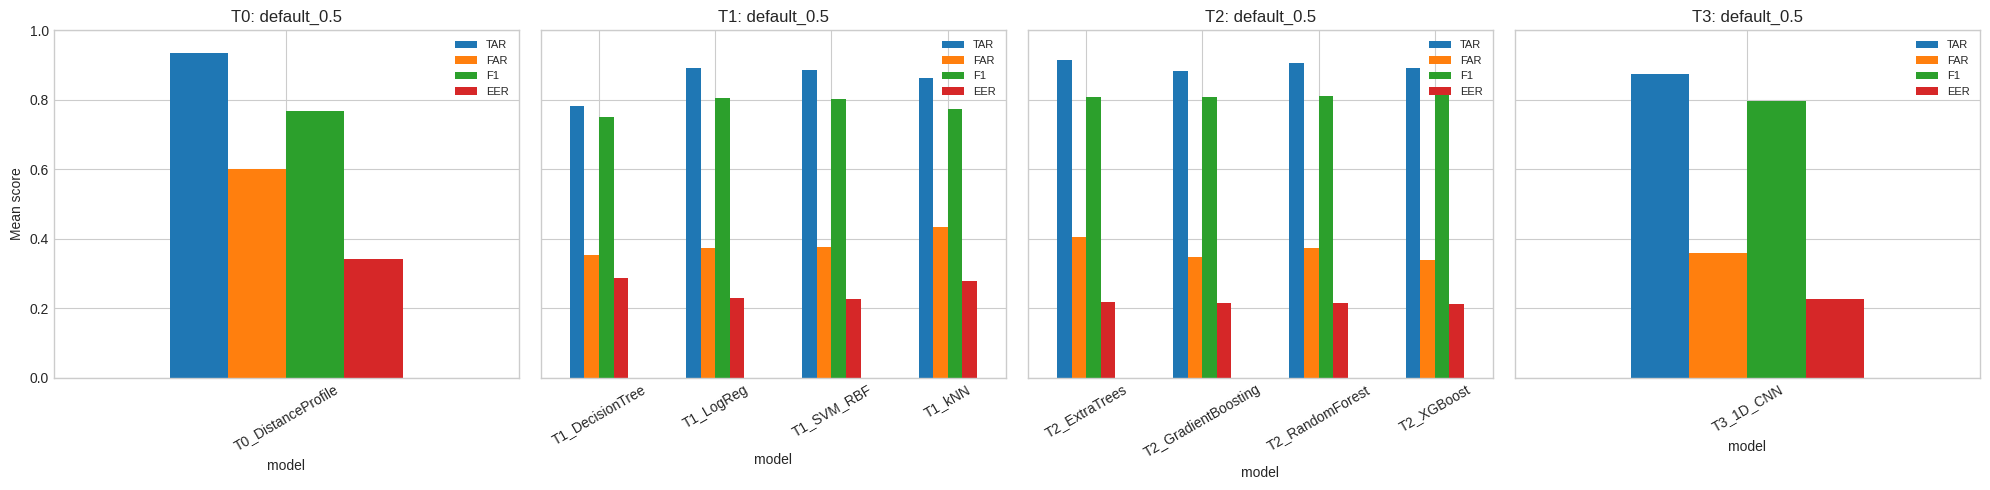

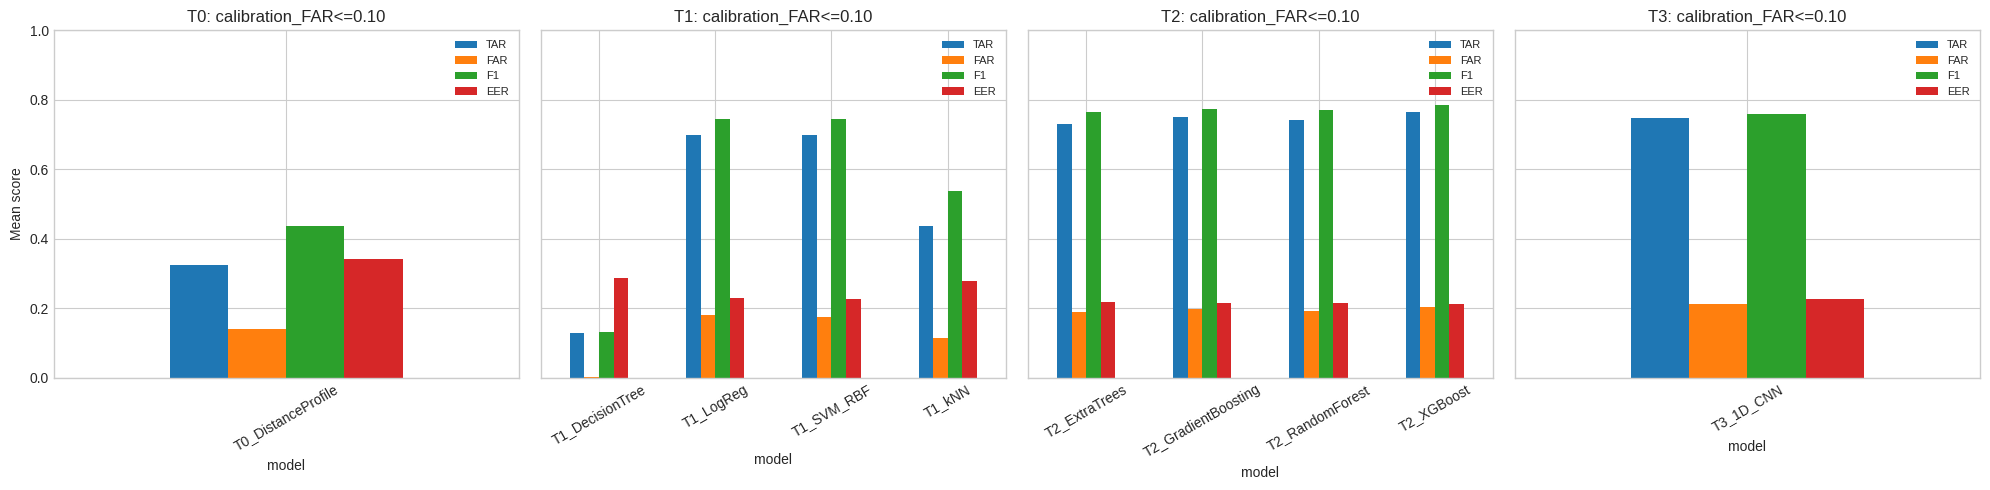

In [ ]:
# plot_metric_by_tier(): bar chart comparing tiers on a chosen metric, for a given threshold policy.
plt.style.use("seaborn-v0_8-whitegrid")

def plot_metric_by_tier(policy="default_0.5"):
    plot_df = (
        fair_results[fair_results["threshold_policy"] == policy]
        .groupby(["tier", "model"])[["TAR", "FAR", "F1", "EER"]]
        .mean()
        .reset_index()
    )
    tiers = [t for t in ["T0", "T1", "T2", "T3"] if t in set(plot_df["tier"])]
    fig, axes = plt.subplots(1, len(tiers), figsize=(5 * len(tiers), 5), sharey=True)
    if len(tiers) == 1:
        axes = [axes]
    for ax, tier_name in zip(axes, tiers):
        tier_plot = plot_df[plot_df["tier"] == tier_name].set_index("model")
        tier_plot[["TAR", "FAR", "F1", "EER"]].plot(kind="bar", ax=ax, rot=30)
        ax.set_title(f"{tier_name}: {policy}")
        ax.set_ylim(0, 1)
        ax.set_ylabel("Mean score")
        ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

plot_metric_by_tier("default_0.5")
plot_metric_by_tier(f"calibration_FAR<={LOW_FAR_TARGET:.2f}")


vulnerability_label
high      34
low       33
medium    33
Name: count, dtype: int64


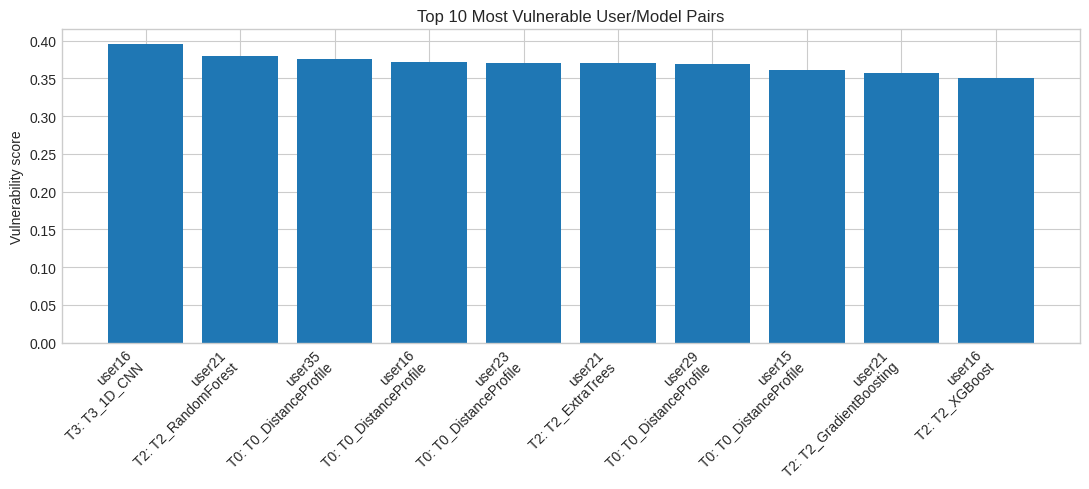

,user,tier,model,FAR,FRR,AUC,EER,vulnerability_score,vulnerability_label
29,user16,T3,T3_1D_CNN,0.339350,0.525950,0.585104,0.431294,0.395330,high
47,user21,T2,T2_RandomForest,0.406746,0.316611,0.695559,0.351738,0.379705,high
70,user35,T0,T0_DistanceProfile,0.219013,0.740467,0.583861,0.438858,0.375449,high
20,user16,T0,T0_DistanceProfile,0.220217,0.726592,0.513928,0.503243,0.372129,high
50,user23,T0,T0_DistanceProfile,0.180418,0.815205,0.497929,0.509096,0.370854,high
45,user21,T2,T2_ExtraTrees,0.378968,0.348941,0.674650,0.367913,0.369960,high
60,user29,T0,T0_DistanceProfile,0.212963,0.735435,0.663271,0.374180,0.369704,high
10,user15,T0,T0_DistanceProfile,0.243056,0.636546,0.626313,0.428300,0.361103,high
46,user21,T2,T2_GradientBoosting,0.361111,0.348941,0.697059,0.345417,0.357460,high
28,user16,T2,T2_XGBoost,0.346570,0.357945,0.713853,0.353728,0.349983,high


In [ ]:
vulnerability_policy = f"calibration_FAR<={LOW_FAR_TARGET:.2f}"
vulnerability = (
    fair_results[fair_results["threshold_policy"] == vulnerability_policy]
    .groupby(["user", "tier", "model"])[["TAR", "FAR", "FRR", "F1", "AUC", "EER"]]
    .mean()
    .reset_index()
)
vulnerability["vulnerability_score"] = 0.7 * vulnerability["FAR"] + 0.3 * vulnerability["FRR"]

# Low/medium/high labels via tertiles of the observed score distribution.
# Quantile-based (rather than fixed cutoffs like 0.25/0.50) keeps the three
# classes roughly balanced regardless of how spread out the scores are,
# which matters with a small number of user/tier/model rows.
vulnerability["vulnerability_label"] = pd.qcut(
    vulnerability["vulnerability_score"], q=3, labels=["low", "medium", "high"]
)
print(vulnerability["vulnerability_label"].value_counts())

top_vulnerable = vulnerability.sort_values("vulnerability_score", ascending=False).head(10).copy()
top_vulnerable["label"] = top_vulnerable["user"] + "\n" + top_vulnerable["tier"] + ": " + top_vulnerable["model"]

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(top_vulnerable["label"], top_vulnerable["vulnerability_score"])
ax.set_title("Top 10 Most Vulnerable User/Model Pairs")
ax.set_ylabel("Vulnerability score")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

top_vulnerable[["user", "tier", "model", "FAR", "FRR", "AUC", "EER", "vulnerability_score", "vulnerability_label"]]


In [ ]:
# Builds `vulnerability_features`: clean-side vulnerability scores merged with
# each user/tier/model's calibrated decision_threshold. Reused below by the
# real Vulnerability Classifier v2 (which merges in actual SapiAgent bypass rate).
vuln_lookup = (
    fair_results[fair_results["threshold_policy"] == vulnerability_policy]
    .groupby(["user", "tier", "model"])[["decision_threshold"]]
    .mean()
    .reset_index()
)
vulnerability_features = vulnerability.merge(vuln_lookup, on=["user", "tier", "model"], how="left")
vulnerability_features.head()


/tmp/ipykernel_1977/353719507.py:27: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_shap, show=True)


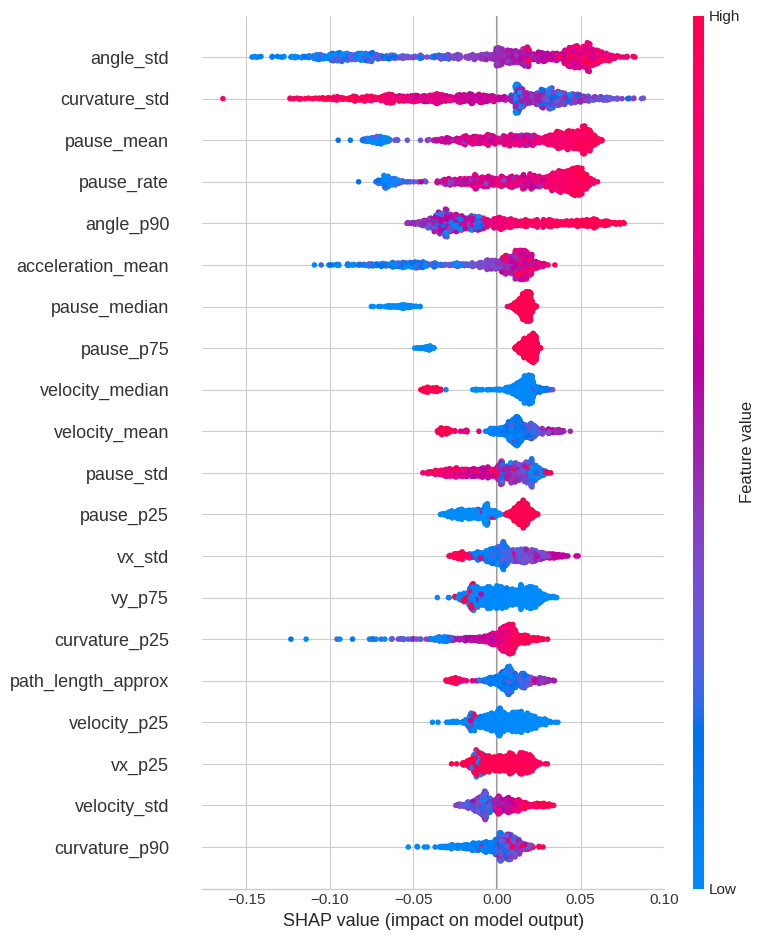

In [ ]:
## SHAP Feature Importance (T2 Tree Models)

# !pip install shap --quiet   # uncomment if not already installed in your Colab session

import shap

def run_user_shap(user, seed=0, model_name="T2_RandomForest"):
    splits = get_fair_user_splits(user, seed=seed)
    models = build_t2_models(seed)
    model = models[model_name]
    model.fit(splits["X_fit_tab"], splits["y_fit"])

    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(splits["X_test_tab"])

    # Handle both SHAP output formats:
    # - old: list of arrays, one per class -> take class 1 ("genuine")
    # - new: single 3D array (samples, features, classes) -> slice class 1
    if isinstance(shap_values, list):
        shap_values = shap_values[1]
    elif isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
        shap_values = shap_values[:, :, 1]

    return shap_values, splits["X_test_tab"]

shap_values, X_shap = run_user_shap(example_user, seed=0, model_name="T2_RandomForest")
shap.summary_plot(shap_values, X_shap, show=True)

In [ ]:
## Multi-User SHAP Consistency Check

def get_user_shap_importance(user, seed=0, model_name="T2_RandomForest"):
    shap_values, X_shap = run_user_shap(user, seed=seed, model_name=model_name)
    mean_abs_shap = np.abs(shap_values).mean(axis=0)
    return pd.Series(mean_abs_shap, index=X_shap.columns)

# Start with a handful of users rather than all 10 - SHAP + retraining per user adds up.
# Widen check_users to sorted(user_counts.keys()) later if this looks useful.
check_users = sorted(user_counts.keys())[:5]

importance_by_user = {}
for u in check_users:
    print(f"Computing SHAP importance for {u}...")
    importance_by_user[u] = get_user_shap_importance(u, seed=0)

importance_df = pd.DataFrame(importance_by_user)  # rows = features, columns = users
importance_df["mean_importance"] = importance_df.mean(axis=1)

# rank_std: how much a feature's rank position jumps around between users.
# Low rank_std + high mean_importance = a feature that's reliably important
# everywhere, not just for one user.
ranks = importance_df[check_users].rank(ascending=False)
importance_df["rank_std"] = ranks.std(axis=1)

top_features = importance_df.sort_values("mean_importance", ascending=False).head(15)
top_features[["mean_importance", "rank_std"] + check_users]

Computing SHAP importance for user12...
Computing SHAP importance for user15...
Computing SHAP importance for user16...
Computing SHAP importance for user20...
Computing SHAP importance for user21...


,mean_importance,rank_std,user12,user15,user16,user20,user21
pause_mean,0.029380,3.346640,0.035068,0.014947,0.032613,0.039844,0.024426
pause_rate,0.026396,3.834058,0.032761,0.014585,0.028503,0.036229,0.019902
curvature_std,0.022736,9.016651,0.038473,0.008382,0.022475,0.027347,0.017003
curvature_p25,0.022667,12.165525,0.012044,0.041578,0.012838,0.004510,0.042363
curvature_p75,0.020012,15.836666,0.003795,0.052637,0.005290,0.006180,0.032157
acceleration_std,0.019343,8.734987,0.006792,0.025783,0.024898,0.012679,0.026562
pause_median,0.017600,12.498000,0.021212,0.004021,0.017374,0.024503,0.020890
curvature_p90,0.016606,17.363755,0.009194,0.037969,0.004935,0.002931,0.028002
angle_std,0.016224,14.808781,0.046677,0.013875,0.004103,0.004165,0.012302
pause_p75,0.014990,9.782638,0.020582,0.005351,0.015152,0.024143,0.009723


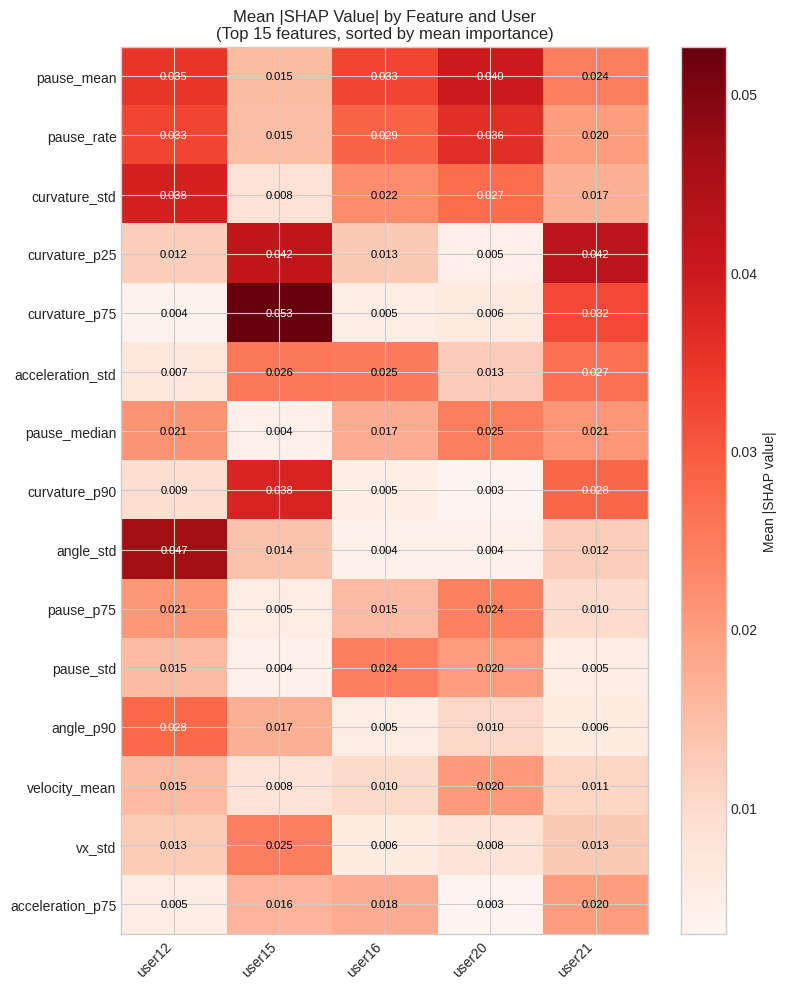

In [ ]:
## SHAP Importance Heatmap Across Users

heatmap_data = top_features[check_users]  # reuse the same top 15 features/users from before

fig, ax = plt.subplots(figsize=(8, 10))
im = ax.imshow(heatmap_data.values, aspect="auto", cmap="Reds")

ax.set_xticks(range(len(check_users)))
ax.set_xticklabels(check_users, rotation=45, ha="right")
ax.set_yticks(range(len(heatmap_data)))
ax.set_yticklabels(heatmap_data.index)

# Annotate each cell with its value for readability.
for i in range(heatmap_data.shape[0]):
    for j in range(heatmap_data.shape[1]):
        val = heatmap_data.values[i, j]
        ax.text(j, i, f"{val:.3f}", ha="center", va="center",
                color="white" if val > heatmap_data.values.max() * 0.5 else "black",
                fontsize=8)

ax.set_title("Mean |SHAP Value| by Feature and User\n(Top 15 features, sorted by mean importance)")
fig.colorbar(im, ax=ax, label="Mean |SHAP value|")
plt.tight_layout()
plt.show()

# Attacker Scoring Infrastructure

Shared functions used by both WindMouse and SapiAgent below: fits each tier's models per user/seed, calibrates thresholds (including the floor variant), and scores attack sessions against them.

In [ ]:
# ================= ALL-TIERS ATTACK BYPASS SCORING (A1 vs A2) =================
# Needs in scope: all_sessions, test_sessions,
# user_counts, get_fair_user_splits, windows_from_sessions, windows_to_tabular,
# threshold_for_target_far, predict_genuine_scores, t0_distance_profile_scores,
# build_t1_models, build_t2_models, build_cnn_fair, and the constants
# (WINDOW, LOW_FAR_TARGET, vulnerability_policy, T3_EPOCHS, T3_VALIDATION_SIZE,
# T3_BATCH_SIZE).
import glob, os
import numpy as np, pandas as pd

ENROLLED_USERS = sorted(user_counts.keys())
ATTACK_SEEDS   = [0, 1, 2]

def load_attack_sessions_by_seed(root, seeds=ATTACK_SEEDS):
    # bare read_csv (already portability-verified); extract_features only needs
    # record timestamp / x / y, which the handoff CSVs have.
    out = {}
    for s in seeds:
        paths = sorted(glob.glob(os.path.join(root, f"seed{s}", "*.csv")))
        out[s] = [pd.read_csv(p) for p in paths]
    return out

def _session_bypassed(win_scores, thr):
    # SESSION RULE (keep identical for BOTH attackers): majority of windows accepted.
    # To use a mean-evidence rule instead, swap for: return win_scores.mean() >= thr
    return float(np.mean(win_scores >= thr)) >= 0.5

def _attack_bypass(score_windows, thr, sessions):
    pooled, sess_flags = [], []
    for sess in sessions:
        Xw, _ = windows_from_sessions([sess], 1)   # per-session windows; label unused
        if len(Xw) == 0:
            continue
        sc = np.asarray(score_windows(Xw), dtype=float)
        pooled.append(sc)
        sess_flags.append(_session_bypassed(sc, thr))
    pooled = np.concatenate(pooled) if pooled else np.array([])
    win_rate  = float(np.mean(pooled >= thr)) if pooled.size else 0.0
    sess_rate = float(np.mean(sess_flags)) if sess_flags else 0.0
    return win_rate, sess_rate

def _tier_scorers(user, seed, t3_epochs):
    # Fit each tier's model(s) on this user's FIT split, calibrate on CAL under
    # BOTH the plain FAR<=0.10 policy and a floored variant (threshold can't
    # drop below THRESHOLD_FLOOR). Returns {(tier, model): (score_windows_fn, {policy_name: threshold})}.
    splits = get_fair_user_splits(user, seed=seed)
    scorers = {}

    def _thresholds(y_cal, cal_scores):
        thr, _, _ = threshold_for_target_far(y_cal, cal_scores, LOW_FAR_TARGET)
        thr_floor, _, _ = threshold_for_target_far(y_cal, cal_scores, LOW_FAR_TARGET, min_threshold=THRESHOLD_FLOOR)
        return {
            f"calibration_FAR<={LOW_FAR_TARGET:.2f}": thr,
            f"calibration_FAR<={LOW_FAR_TARGET:.2f}_floor_{THRESHOLD_FLOOR:.2f}": thr_floor,
        }

    # T0 distance profile
    def t0_score(Xw, _s=splits):
        return t0_distance_profile_scores(_s["X_fit_tab"], _s["y_fit"], windows_to_tabular(Xw))
    cal = t0_distance_profile_scores(splits["X_fit_tab"], splits["y_fit"], splits["X_cal_tab"])
    scorers[("T0", "T0_DistanceProfile")] = (t0_score, _thresholds(splits["y_cal"], cal))

    # T1 + T2 tabular sklearn
    for tier, builder in [("T1", build_t1_models), ("T2", build_t2_models)]:
        for name, model in builder(seed).items():
            model.fit(splits["X_fit_tab"], splits["y_fit"])
            cal = predict_genuine_scores(model, splits["X_cal_tab"])
            scorers[(tier, name)] = (
                (lambda Xw, m=model: predict_genuine_scores(m, windows_to_tabular(Xw))),
                _thresholds(splits["y_cal"], cal))

    # T3 1D-CNN on sequences (same train/val split + scaler as run_user_t3_fair)
    np.random.seed(seed); pyrandom.seed(seed); tf.random.set_seed(seed)
    fit_idx = np.arange(len(splits["y_fit"]))
    tr_idx, val_idx = train_test_split(fit_idx, test_size=T3_VALIDATION_SIZE,
                                       stratify=splits["y_fit"], random_state=seed)
    f = splits["X_fit_seq"].shape[2]
    scaler = StandardScaler().fit(splits["X_fit_seq"][tr_idx].reshape(-1, f))
    def _scale(seq): return scaler.transform(seq.reshape(-1, f)).reshape(seq.shape)
    cnn = build_cnn_fair(input_shape=(WINDOW, f))
    es = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True)
    cnn.fit(_scale(splits["X_fit_seq"][tr_idx]), splits["y_fit"][tr_idx],
            validation_data=(_scale(splits["X_fit_seq"][val_idx]), splits["y_fit"][val_idx]),
            epochs=t3_epochs, batch_size=T3_BATCH_SIZE, callbacks=[es], verbose=0)
    cal = cnn.predict(_scale(splits["X_cal_seq"]), verbose=0).ravel()
    def t3_score(Xw, _c=cnn, _sc=_scale): return _c.predict(_sc(Xw), verbose=0).ravel()
    scorers[("T3", "T3_1D_CNN")] = (t3_score, _thresholds(splits["y_cal"], cal))
    return scorers

import time

def score_attack_all_tiers(attack_by_seed, attack_type, t3_epochs=T3_EPOCHS,
                           users=ENROLLED_USERS, seeds=ATTACK_SEEDS):
    # Pairs defender(seed) with that seed's attack sessions. One row per
    # (user, tier, model, threshold_policy, seed) - now scored against BOTH
    # the plain FAR<=0.10 threshold and the floored variant, for direct comparison.
    _t0 = time.time()
    rows = []
    for seed in seeds:
        sessions = attack_by_seed[seed]
        for user in users:
            print(f"[{attack_type}] seed={seed} user={user} elapsed={time.time()-_t0:.1f}s")
            for (tier, model_name), (score_fn, thr_dict) in _tier_scorers(user, seed, t3_epochs).items():
                for policy_name, thr in thr_dict.items():
                    wr, sr = _attack_bypass(score_fn, thr, sessions)
                    rows.append({"user": user, "tier": tier, "model": model_name,
                                 "threshold_policy": policy_name, "attack_type": attack_type,
                                 "seed": seed, "accept_threshold": thr,
                                 "bypass_rate_window": wr, "bypass_rate_session": sr})
        print(f"[{attack_type}] seed {seed} done - elapsed={time.time()-_t0:.1f}s")
    print(f"[{attack_type}] fully done in {time.time()-_t0:.1f}s")
    return pd.DataFrame(rows)

## Confidence Intervals for Rates (Week 8 fix)

Per feedback: a 100% rate from a handful of sessions is not equivalent to a 100% rate from hundreds of independent attempts. Every rate reported from here on should go through `rate_with_ci()` so the sample size and uncertainty are visible, not just the point estimate.

In [ ]:
def wilson_interval(successes, total, z=1.96):
    """95% Wilson confidence interval for a proportion. More reliable than a normal
    approximation when the count is small or the rate is near 0% or 100%."""
    if total == 0:
        return (np.nan, np.nan)
    p = successes / total
    denom = 1 + z**2 / total
    center = (p + z**2 / (2 * total)) / denom
    margin = z * np.sqrt((p * (1 - p) + z**2 / (4 * total)) / total) / denom
    return (max(0.0, center - margin), min(1.0, center + margin))

def rate_with_ci(successes, total):
    """Returns a string like '61.7% (n=60, 95% CI: 48.2-73.9%)' instead of a bare percentage."""
    if total == 0:
        return "n/a (n=0)"
    p = successes / total
    lo, hi = wilson_interval(successes, total)
    return f"{p*100:.1f}% (n={total}, 95% CI: {lo*100:.1f}-{hi*100:.1f}%)"


# Attacker Results: WindMouse

Two versions below: the original T3-only result (from the partner's earlier run, hardcoded), and a new all-tiers run scored using the same infrastructure as SapiAgent, so the two attackers can be compared directly across every tier.

In [ ]:
## Robustness Drop (Clean FAR vs. Attack Bypass Rate)

# REAL attack_results from the partner's WindMouse (T6) run.
# Source: Week5REU_BehavioralAuth_final_fair_T0_T1_T2_T3.ipynb,
#   run_windmouse_t6(n_attack_sessions=20, seeds=[0,1,2]), policy
#   calibration_FAR<=0.10, bypass rates averaged over the 3 seeds.
# WindMouse was scored against the T3 1D-CNN (the deployed sequence defender),
# so every row is tier="T3", model="T3_1D_CNN" to match fair_results and let
# the clean-FAR merge below resolve. NOTE: only T3 was tested for WindMouse -
# unlike SapiAgent (all four tiers) below. Ask partner for all-tier WindMouse
# results if a like-for-like comparison across tiers is needed.
# Uses attack_results_windmouse (not attack_results) so it does not get
# silently overwritten by the SapiAgent run later in this notebook.

ATTACK_RESULTS_READY = True

# (bypass_rate_window, bypass_rate_session) per user, seed-averaged, FAR<=0.10.
windmouse_bypass = {
    "user15": (0.798146, 0.950000),
    "user9":  (0.699536, 0.933333),
    "user23": (0.652528, 0.700000),
    "user35": (0.237637, 0.000000),
    "user12": (0.174365, 0.000000),
    "user7":  (0.094203, 0.016667),
    "user16": (0.087179, 0.000000),
    "user29": (0.082051, 0.016667),
    "user21": (0.000000, 0.000000),
    "user20": (0.000000, 0.000000),
}

attack_results_windmouse = pd.DataFrame(
    [
        {
            "user": u,
            "tier": "T3",
            "model": "T3_1D_CNN",
            "threshold_policy": vulnerability_policy,   # "calibration_FAR<=0.10"
            "attack_type": "windmouse",
            "bypass_rate_window": bw,
            "bypass_rate_session": bs,
        }
        for u, (bw, bs) in windmouse_bypass.items()
    ]
)

# Guard: every attacked user must exist in the clean T3 results, else the merge
# below silently yields NaN clean_FAR.
_clean_users = set(
    fair_results[
        (fair_results["threshold_policy"] == vulnerability_policy)
        & (fair_results["tier"] == "T3")
        & (fair_results["model"] == "T3_1D_CNN")
    ]["user"]
)
_missing = set(attack_results_windmouse["user"]) - _clean_users
assert not _missing, f"attack_results users missing from clean T3 fair_results: {_missing}"
print(f"Loaded REAL WindMouse attack_results_windmouse: {len(attack_results_windmouse)} rows, "
      f"{attack_results_windmouse['user'].nunique()} users, tier=T3/T3_1D_CNN.")

# --- Robustness drop computation (unchanged from the handoff contract) ---
clean_far = (
    fair_results[fair_results["threshold_policy"] == vulnerability_policy]
    .groupby(["user", "tier", "model"])[["FAR"]]
    .mean()
    .reset_index()
    .rename(columns={"FAR": "clean_FAR"})
)

robustness_windmouse = attack_results_windmouse.merge(clean_far, on=["user", "tier", "model"], how="left")
robustness_windmouse["robustness_drop_window"] = robustness_windmouse["bypass_rate_window"] - robustness_windmouse["clean_FAR"]
robustness_windmouse["robustness_drop_session"] = robustness_windmouse["bypass_rate_session"] - robustness_windmouse["clean_FAR"]

# Only 10 rows here (one per user, T3 only) - this is the WindMouse robustness
# table, separate from the SapiAgent one (all tiers) further down.
robustness_windmouse.sort_values("robustness_drop_window", ascending=False)[
    ["user", "tier", "model", "attack_type", "clean_FAR", "bypass_rate_window",
     "robustness_drop_window", "bypass_rate_session", "robustness_drop_session"]
].head(15)

Loaded REAL WindMouse attack_results: 10 rows, 10 users, tier=T3/T3_1D_CNN.


,user,tier,model,attack_type,clean_FAR,bypass_rate_window,robustness_drop_window,bypass_rate_session,robustness_drop_session
1,user9,T3,T3_1D_CNN,windmouse,0.013382,0.699536,0.686154,0.933333,0.919951
0,user15,T3,T3_1D_CNN,windmouse,0.302350,0.798146,0.495796,0.950000,0.647650
2,user23,T3,T3_1D_CNN,windmouse,0.184818,0.652528,0.467710,0.700000,0.515182
5,user7,T3,T3_1D_CNN,windmouse,0.004049,0.094203,0.090154,0.016667,0.012618
9,user20,T3,T3_1D_CNN,windmouse,0.000000,0.000000,0.000000,0.000000,0.000000
4,user12,T3,T3_1D_CNN,windmouse,0.180015,0.174365,-0.005650,0.000000,-0.180015
3,user35,T3,T3_1D_CNN,windmouse,0.388688,0.237637,-0.151051,0.000000,-0.388688
6,user16,T3,T3_1D_CNN,windmouse,0.339350,0.087179,-0.252171,0.000000,-0.339350
7,user29,T3,T3_1D_CNN,windmouse,0.379630,0.082051,-0.297579,0.016667,-0.362963
8,user21,T3,T3_1D_CNN,windmouse,0.317460,0.000000,-0.317460,0.000000,-0.317460


In [ ]:
## Dr. Duan: aggregate bypass across ALL users
# Uses attack_results_windmouse (not attack_results, which holds SapiAgent data below)
wm = attack_results_windmouse[attack_results_windmouse["attack_type"] == "windmouse"]
for col in ["bypass_rate_session", "bypass_rate_window"]:
    s = wm[col]
    print(f"{col}: mean={s.mean():.3f}  std={s.std():.3f}  median={s.median():.3f}  "
          f"min={s.min():.3f}  max={s.max():.3f}")
    print(f"  users >0.70: {(s > 0.70).sum()} / {len(s)}   at 0.00: {(s == 0).sum()} / {len(s)}")

bypass_rate_session: mean=0.262  std=0.419  median=0.008  min=0.000  max=0.950
  users >0.70: 2 / 10   at 0.00: 5 / 10
bypass_rate_window: mean=0.283  std=0.310  median=0.134  min=0.000  max=0.798
  users >0.70: 1 / 10   at 0.00: 2 / 10


## WindMouse (All Tiers) - Scored by Us

Same scoring infrastructure used for SapiAgent above, applied to the raw WindMouse session files, so both attackers are directly comparable across all four tiers rather than just T3.

In [ ]:
# Loads the raw WindMouse attack session CSVs (seed0/seed1/seed2) from Drive.
# Expect 20 sessions per seed - if any print 0, the files aren't at this path yet.
windmouse_by_seed = load_attack_sessions_by_seed("/content/drive/MyDrive/handoff/windmouse_sessions")
for s in [0, 1, 2]:
    print(f"seed {s}: {len(windmouse_by_seed[s])} sessions loaded")


In [ ]:
# Same scoring pipeline used for SapiAgent - now gives WindMouse across all
# four tiers instead of just T3, so it is directly comparable to SapiAgent's
# results below. Retrains T1/T2/T3 per user/seed, so expect similar runtime
# to the SapiAgent full run above.
windmouse_all_tiers_rows = score_attack_all_tiers(windmouse_by_seed, "windmouse_all_tiers", t3_epochs=T3_EPOCHS)
windmouse_all_tiers_rows.to_csv("/content/drive/MyDrive/windmouse_all_tiers_with_floor.csv", index=False)
print("rows:", len(windmouse_all_tiers_rows), "| tiers:", sorted(windmouse_all_tiers_rows.tier.unique()))


# Attacker Results: SapiAgent (All Tiers)

SapiAgent covers all four tiers (T0-T3), scored against both the plain FAR<=0.10 threshold and the floored variant (`calibration_FAR<=0.10_floor_0.05`) for direct comparison.

In [ ]:
sapi_by_seed = load_attack_sessions_by_seed("/content/drive/MyDrive/handoff/sapiagent_sessions")

In [ ]:
# Loads the raw SapiAgent attack session CSVs (seed0/seed1/seed2) from Drive.
# Expect 20 sessions per seed - if any print 0, the files aren't at this path yet.
import glob
print(len(glob.glob("/content/drive/MyDrive/handoff/sapiagent_sessions/seed0/*.csv")))  # expect 20

20


In [ ]:
# SMOKE: one user, one seed, few epochs. Expect a small table with sane 0..1 rates.
_smoke = score_attack_all_tiers({0: sapi_by_seed[0]}, "sapiagent_smoke",
                                t3_epochs=5, users=[ENROLLED_USERS[0]], seeds=[0])
display(_smoke[["tier","model","accept_threshold","bypass_rate_window","bypass_rate_session"]])

[sapiagent_smoke] seed=0 user=user12 elapsed=0.0s
[sapiagent_smoke] seed 0 done - elapsed=83.7s
[sapiagent_smoke] fully done in 83.7s


,tier,model,accept_threshold,bypass_rate_window,bypass_rate_session
0,T0,T0_DistanceProfile,0.692709,0.000000,0.0
1,T0,T0_DistanceProfile,0.692709,0.000000,0.0
2,T1,T1_LogReg,0.714436,0.104167,0.0
3,T1,T1_LogReg,0.714436,0.104167,0.0
4,T1,T1_SVM_RBF,0.754716,0.000000,0.0
5,T1,T1_SVM_RBF,0.754716,0.000000,0.0
6,T1,T1_kNN,1.000000,0.137500,0.0
7,T1,T1_kNN,1.000000,0.137500,0.0
8,T1,T1_DecisionTree,1.000000,0.000000,0.0
9,T1,T1_DecisionTree,1.000000,0.000000,0.0


In [ ]:
# FULL run (T3 refits 10 users x 3 seeds = the slow part; keep T3_EPOCHS for final numbers)
# `attack_results` here = SapiAgent only, all four tiers, both threshold policies.
# WindMouse's data lives separately in `attack_results_windmouse` (T3 only) above -
# no more collision since the rename, but they are still analyzed separately, not combined.
sapi_rows = score_attack_all_tiers(sapi_by_seed, "sapiagent", t3_epochs=T3_EPOCHS)

attack_results = sapi_rows.copy()
attack_results.to_csv("/content/drive/MyDrive/attack_results_all_tiers_with_floor.csv", index=False)  # new filename - does not overwrite the original
print("rows:", len(attack_results), "| tiers:", sorted(attack_results.tier.unique()))

[sapiagent] seed=0 user=user12 elapsed=0.0s
[sapiagent] seed=0 user=user15 elapsed=89.3s
[sapiagent] seed=0 user=user16 elapsed=161.9s
[sapiagent] seed=0 user=user20 elapsed=244.2s
[sapiagent] seed=0 user=user21 elapsed=334.5s
[sapiagent] seed=0 user=user23 elapsed=401.0s
[sapiagent] seed=0 user=user29 elapsed=467.3s
[sapiagent] seed=0 user=user35 elapsed=530.0s
[sapiagent] seed=0 user=user7 elapsed=590.2s
[sapiagent] seed=0 user=user9 elapsed=695.1s
[sapiagent] seed 0 done - elapsed=796.5s
[sapiagent] seed=1 user=user12 elapsed=796.5s
[sapiagent] seed=1 user=user15 elapsed=879.1s
[sapiagent] seed=1 user=user16 elapsed=945.9s
[sapiagent] seed=1 user=user20 elapsed=1025.9s
[sapiagent] seed=1 user=user21 elapsed=1115.7s
[sapiagent] seed=1 user=user23 elapsed=1182.6s
[sapiagent] seed=1 user=user29 elapsed=1246.0s
[sapiagent] seed=1 user=user35 elapsed=1309.2s
[sapiagent] seed=1 user=user7 elapsed=1375.4s
[sapiagent] seed=1 user=user9 elapsed=1482.0s
[sapiagent] seed 1 done - elapsed=1583.

In [ ]:
# The real, full attack-scoring run: retrains T1/T2/T3 per user/seed and scores SapiAgent
# against both threshold policies. This is the slow step (~similar to the fair_results run).
# Output: `attack_results`, ~600 rows (10 users x 10 models x 2 policies x 3 seeds).
sa = attack_results[attack_results.attack_type == "sapiagent"]

# Dr. Duan: aggregate per defender, seed-averaged per user, report spread + bimodal shape
per_user = sa.groupby(["tier","model","user"])["bypass_rate_session"].mean().reset_index()
agg = per_user.groupby(["tier","model"])["bypass_rate_session"].agg(
    mean="mean", std="std", median="median",
    n_over_0p70=lambda x: int((x > 0.70).sum()), n_at_0=lambda x: int((x == 0).sum()))
display(agg.round(3))   # T3_1D_CNN row is the direct comparison to WindMouse's 0.262

# Paradox for A2: AUC should NOT predict bypass (~0); decision threshold should (negative)
far = fair_results[fair_results.threshold_policy == vulnerability_policy]
merged = sa.merge(far[["user","tier","model","seed","AUC","decision_threshold"]],
                  on=["user","tier","model","seed"], how="left")
for x in ["AUC", "decision_threshold"]:
    for y in ["bypass_rate_session", "bypass_rate_window"]:
        print(f"corr({x}, {y}) = {merged[[x,y]].dropna().corr().iloc[0,1]:+.3f}")

mean    std  median  n_over_0p70  n_at_0
tier model                                                         
T0   T0_DistanceProfile   0.000  0.000   0.000            0      10
T1   T1_DecisionTree      0.015  0.047   0.000            0       9
     T1_LogReg            0.202  0.421   0.000            2       7
     T1_SVM_RBF           0.100  0.316   0.000            1       9
     T1_kNN               0.060  0.127   0.000            0       8
T2   T2_ExtraTrees        0.003  0.011   0.000            0       9
     T2_GradientBoosting  0.088  0.167   0.000            0       7
     T2_RandomForest      0.000  0.000   0.000            0      10
     T2_XGBoost           0.057  0.135   0.000            0       8
T3   T3_1D_CNN            0.200  0.276   0.108            1       4

corr(AUC, bypass_rate_session) = -0.004
corr(AUC, bypass_rate_window) = +0.002
corr(decision_threshold, bypass_rate_session) = -0.124
corr(decision_threshold, bypass_rate_window) = -0.134


In [ ]:
# Aggregates SapiAgent bypass rate per tier/model across users - reports mean/std/median
# and how many user/model pairs exceed 0.70 bypass vs. exactly 0 (bimodal shape check).
# Also checks correlation of AUC/decision_threshold with bypass rate.
sa = attack_results[attack_results.attack_type == "sapiagent"]
t3 = (sa[sa.model == "T3_1D_CNN"]
      .groupby("user")["bypass_rate_session"].mean()
      .sort_values(ascending=False))
print(t3.round(3))

user
user21    0.867
user12    0.400
user35    0.267
user16    0.250
user9     0.200
user23    0.017
user15    0.000
user20    0.000
user29    0.000
user7     0.000
Name: bypass_rate_session, dtype: float64


In [ ]:
# T3-specific bypass rates per user, sorted descending - quick look at which users are
# most vulnerable specifically on the CNN tier.
agg.to_csv("/content/drive/MyDrive/sapiagent_bypass_by_tier_with_floor.csv")  # new filename - does not overwrite the original

In [ ]:
# Saves the per-tier SapiAgent aggregate table to Drive (does not overwrite the original filename).
attack_results.groupby("threshold_policy")[["bypass_rate_window", "bypass_rate_session"]].mean()

,bypass_rate_window,bypass_rate_session
threshold_policy,,
calibration_FAR<=0.10,0.092153,0.0745
calibration_FAR<=0.10_floor_0.05,0.087750,0.0705


In [ ]:
# Main comparison: mean bypass rate with vs. without the threshold floor, across all rows.
pivot = (
    attack_results[attack_results["user"].isin(["user9", "user20", "user7", "user16", "user21", "user29"])]
    .groupby(["user", "tier", "model", "threshold_policy"])[["accept_threshold", "bypass_rate_session"]]
    .mean()
    .unstack("threshold_policy")
)
pivot

accept_threshold  \
threshold_policy                calibration_FAR<=0.10   
user   tier model                                       
user16 T0   T0_DistanceProfile               0.702498   
       T1   T1_DecisionTree                  1.000000   
            T1_LogReg                        0.748470   
            T1_SVM_RBF                       0.769288   
            T1_kNN                           1.000000   
       T2   T2_ExtraTrees                    0.725556   
            T2_GradientBoosting              0.742055   
            T2_RandomForest                  0.713333   
            T2_XGBoost                       0.748773   
       T3   T3_1D_CNN                        0.588578   
user20 T0   T0_DistanceProfile               0.665840   
       T1   T1_DecisionTree                  1.000000   
            T1_LogReg                        0.677363   
            T1_SVM_RBF                       0.734597   
            T1_kNN                           1.000000   
       T2   T2_ExtraTrees                    0.647778   
            T2_GradientBoosting              0.658871   
            T2_RandomForest                  0.633333   
            T2_XGBoost                       0.655773   
       T3   T3_1D_CNN                        0.720929   
user21 T0   T0_DistanceProfile               0.703585   
       T1   T1_DecisionTree                  1.000000   
            T1_LogReg                        0.704663   
            T1_SVM_RBF                       0.738969   
            T1_kNN                           1.000000   
       T2   T2_ExtraTrees                    0.678889   
            T2_GradientBoosting              0.720613   
            T2_RandomForest                  0.647778   
            T2_XGBoost                       0.739638   
       T3   T3_1D_CNN                        0.814738   
user29 T0   T0_DistanceProfile               0.677787   
       T1   T1_DecisionTree                  1.000000   
            T1_LogReg                        0.591029   
            T1_SVM_RBF                       0.700514   
            T1_kNN                           0.866667   
       T2   T2_ExtraTrees                    0.588889   
            T2_GradientBoosting              0.605342   
            T2_RandomForest                  0.580000   
            T2_XGBoost                       0.612557   
       T3   T3_1D_CNN                        0.503989   
user7  T0   T0_DistanceProfile               0.630187   
       T1   T1_DecisionTree                  1.000000   
            T1_LogReg                        0.611428   
            T1_SVM_RBF                       0.520212   
            T1_kNN                           1.000000   
       T2   T2_ExtraTrees                    0.577778   
            T2_GradientBoosting              0.580753   
            T2_RandomForest                  0.566667   
            T2_XGBoost                       0.486810   
       T3   T3_1D_CNN                        0.281828   
user9  T0   T0_DistanceProfile               0.651016   
       T1   T1_DecisionTree                  1.000000   
            T1_LogReg                        0.128944   
            T1_SVM_RBF                       0.056479   
            T1_kNN                           0.600000   
       T2   T2_ExtraTrees                    0.173333   
            T2_GradientBoosting              0.066807   
            T2_RandomForest                  0.152222   
            T2_XGBoost                       0.023406   
       T3   T3_1D_CNN                        0.000256   

                                                                  \
threshold_policy                calibration_FAR<=0.10_floor_0.05   
user   tier model                                                  
user16 T0   T0_DistanceProfile                          0.702498   
       T1   T1_DecisionTree                             1.000000   
            T1_LogReg                                   0.748470   
            T1_SVM_RBF               

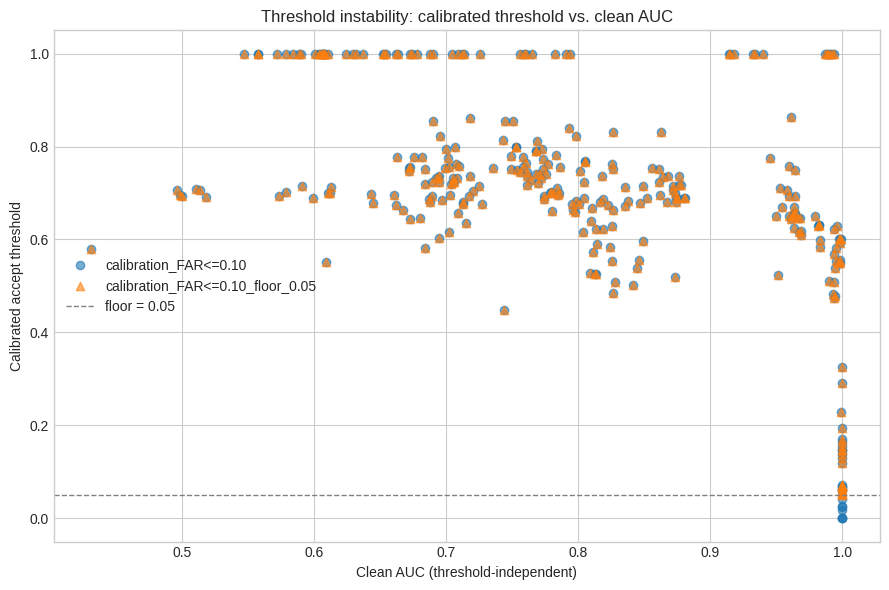

In [ ]:
## Threshold Instability: Calibrated Threshold vs. Clean AUC (floor vs. no floor)

import matplotlib.pyplot as plt

# AUC is threshold-independent, so any policy row gives the same AUC per user/tier/model/seed
clean_auc = (
    fair_results[fair_results["threshold_policy"] == "default_0.5"]
    [["user", "tier", "model", "seed", "AUC"]]
)

plot_df = attack_results.merge(clean_auc, on=["user", "tier", "model", "seed"], how="left")

fig, ax = plt.subplots(figsize=(9, 6))
for policy, marker in [
    ("calibration_FAR<=0.10", "o"),
    (f"calibration_FAR<=0.10_floor_{THRESHOLD_FLOOR:.2f}", "^"),
]:
    sub = plot_df[plot_df["threshold_policy"] == policy]
    ax.scatter(sub["AUC"], sub["accept_threshold"], label=policy, alpha=0.6, marker=marker)

ax.axhline(THRESHOLD_FLOOR, linestyle="--", linewidth=1, color="gray", label=f"floor = {THRESHOLD_FLOOR}")
ax.set_xlabel("Clean AUC (threshold-independent)")
ax.set_ylabel("Calibrated accept threshold")
ax.set_title("Threshold instability: calibrated threshold vs. clean AUC")
ax.legend()
plt.tight_layout()
plt.show()

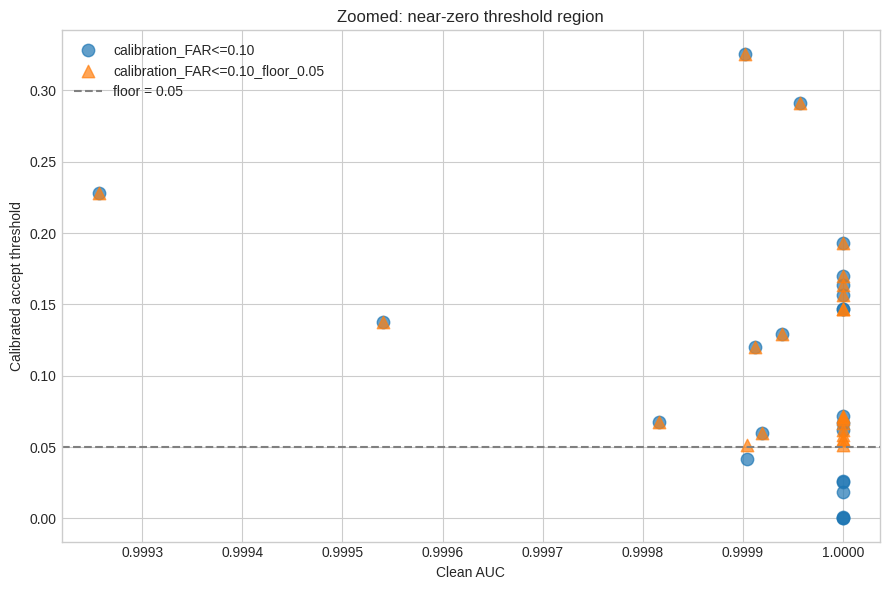

In [ ]:
fig, ax = plt.subplots(figsize=(9, 6))
zoom = plot_df[(plot_df["AUC"] > 0.9) & (plot_df["accept_threshold"] < 0.35)]
for policy, marker in [
    ("calibration_FAR<=0.10", "o"),
    (f"calibration_FAR<=0.10_floor_{THRESHOLD_FLOOR:.2f}", "^"),
]:
    sub = zoom[zoom["threshold_policy"] == policy]
    ax.scatter(sub["AUC"], sub["accept_threshold"], label=policy, alpha=0.7, marker=marker, s=80)
ax.axhline(THRESHOLD_FLOOR, linestyle="--", color="gray", label=f"floor = {THRESHOLD_FLOOR}")
ax.set_xlabel("Clean AUC")
ax.set_ylabel("Calibrated accept threshold")
ax.set_title("Zoomed: near-zero threshold region")
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
plot_df[(plot_df["accept_threshold"] < 0.01) & (plot_df["threshold_policy"] == "calibration_FAR<=0.10")][["user", "tier", "model", "seed", "AUC", "accept_threshold"]]

,user,tier,model,seed,AUC,accept_threshold
198,user9,T3,T3_1D_CNN,0,1.0,0.000024
398,user9,T3,T3_1D_CNN,1,1.0,0.000090
598,user9,T3,T3_1D_CNN,2,1.0,0.000653


# Threshold-Floor Sweep (Week 8 fix)

**Feedback:** the threshold-floor correction currently appears motivated primarily by one user/CNN configuration. This section sweeps several floor values across every user, tier, and seed, and reports the effect on bypass rate, FAR, FRR, TAR, and EER - showing whether 0.05 is a generally good choice or just what happened to fix that one case.

Needs `sapi_by_seed` and `windmouse_by_seed` already loaded (from the attacker-results sections above).

In [ ]:
FLOOR_SWEEP_VALUES = [0.0, 0.02, 0.05, 0.08, 0.10, 0.15, 0.20]

def _floor_thresholds(y_cal, cal_scores, floors=FLOOR_SWEEP_VALUES):
    out = {}
    for floor in floors:
        thr, _, _ = threshold_for_target_far(y_cal, cal_scores, LOW_FAR_TARGET, min_threshold=floor)
        out[floor] = thr
    return out

def run_user_floor_sweep(user, seed, t3_epochs=T3_EPOCHS, attack_session_sets=None):
    """attack_session_sets: dict like {"sapiagent": sapi_by_seed[seed], "windmouse": windmouse_by_seed[seed]}.
    Refits each tier ONCE per user/seed (not once per floor) - only the threshold search
    is repeated per floor, so this is not floors-times-slower than a single run."""
    splits = get_fair_user_splits(user, seed=seed)
    rows = []

    def _eval_clean(test_scores, thr):
        y_pred = (test_scores >= thr).astype(int)
        tn, fp, fn, tp = confusion_matrix(splits["y_test"], y_pred, labels=[0, 1]).ravel()
        tar = tp / (tp + fn) if (tp + fn) else 0.0
        far = fp / (fp + tn) if (fp + tn) else 0.0
        return tar, far, 1 - tar

    def _score_attacks(score_fn, thr):
        out = {}
        if attack_session_sets:
            for atk_name, sessions in attack_session_sets.items():
                if sessions:
                    _, sr = _attack_bypass(score_fn, thr, sessions)
                    out[atk_name] = sr
        return out

    tier_defs = []

    cal0 = t0_distance_profile_scores(splits["X_fit_tab"], splits["y_fit"], splits["X_cal_tab"])
    test0 = t0_distance_profile_scores(splits["X_fit_tab"], splits["y_fit"], splits["X_test_tab"])
    def score0(Xw, _s=splits): return t0_distance_profile_scores(_s["X_fit_tab"], _s["y_fit"], windows_to_tabular(Xw))
    tier_defs.append(("T0", "T0_DistanceProfile", cal0, test0, score0))

    for tier, builder in [("T1", build_t1_models), ("T2", build_t2_models)]:
        for name, model in builder(seed).items():
            model.fit(splits["X_fit_tab"], splits["y_fit"])
            cal = predict_genuine_scores(model, splits["X_cal_tab"])
            test = predict_genuine_scores(model, splits["X_test_tab"])
            def score_fn(Xw, m=model): return predict_genuine_scores(m, windows_to_tabular(Xw))
            tier_defs.append((tier, name, cal, test, score_fn))

    np.random.seed(seed); pyrandom.seed(seed); tf.random.set_seed(seed)
    fit_idx = np.arange(len(splits["y_fit"]))
    tr_idx, val_idx = train_test_split(fit_idx, test_size=T3_VALIDATION_SIZE, stratify=splits["y_fit"], random_state=seed)
    f = splits["X_fit_seq"].shape[2]
    scaler = StandardScaler().fit(splits["X_fit_seq"][tr_idx].reshape(-1, f))
    def _scale(seq): return scaler.transform(seq.reshape(-1, f)).reshape(seq.shape)
    cnn = build_cnn_fair(input_shape=(WINDOW, f))
    es = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True)
    cnn.fit(_scale(splits["X_fit_seq"][tr_idx]), splits["y_fit"][tr_idx],
            validation_data=(_scale(splits["X_fit_seq"][val_idx]), splits["y_fit"][val_idx]),
            epochs=t3_epochs, batch_size=T3_BATCH_SIZE, callbacks=[es], verbose=0)
    cal3 = cnn.predict(_scale(splits["X_cal_seq"]), verbose=0).ravel()
    test3 = cnn.predict(_scale(splits["X_test_seq"]), verbose=0).ravel()
    def score3(Xw, _c=cnn, _sc=_scale): return _c.predict(_sc(Xw), verbose=0).ravel()
    tier_defs.append(("T3", "T3_1D_CNN", cal3, test3, score3))

    for tier, model_name, cal_scores, test_scores, score_fn in tier_defs:
        floor_thr = _floor_thresholds(splits["y_cal"], cal_scores)
        cal_eer, _ = compute_eer_threshold(splits["y_cal"], cal_scores)
        for floor, thr in floor_thr.items():
            tar, far, frr = _eval_clean(test_scores, thr)
            attack_bypass = _score_attacks(score_fn, thr)
            row = {"user": user, "seed": seed, "tier": tier, "model": model_name,
                   "floor": floor, "accept_threshold": thr,
                   "TAR": tar, "FAR": far, "FRR": frr, "EER": cal_eer}
            row.update({f"bypass_{k}": v for k, v in attack_bypass.items()})
            rows.append(row)
    return pd.DataFrame(rows)


In [ ]:
# Run the sweep across all users and seeds. This is the slow step (refits T1/T2/T3
# per user/seed, same cost as one full fair_results pass) - run once, save to CSV.
floor_sweep_rows = []
for seed in FAIR_SEEDS:
    attack_sets = {
        "sapiagent": sapi_by_seed.get(seed, []) if "sapi_by_seed" in dir() else [],
        "windmouse": windmouse_by_seed.get(seed, []) if "windmouse_by_seed" in dir() else [],
    }
    for user in sorted(user_counts.keys()):
        print(f"floor sweep: seed={seed} user={user}")
        floor_sweep_rows.append(run_user_floor_sweep(user, seed, attack_session_sets=attack_sets))

floor_sweep_results = pd.concat(floor_sweep_rows, ignore_index=True)
floor_sweep_results.to_csv("/content/drive/MyDrive/threshold_floor_sweep_results.csv", index=False)
print("rows:", len(floor_sweep_results))


In [ ]:
# Does the floor generalize, or was 0.05 a one-off? Mean effect per floor value,
# across every user/tier/model/seed - not just the one case that motivated it.
floor_summary = (
    floor_sweep_results
    .groupby("floor")[["TAR", "FAR", "FRR"] + [c for c in floor_sweep_results.columns if c.startswith("bypass_")]]
    .mean()
    .round(4)
)
floor_summary


In [ ]:
# Usability (TAR) vs. security (bypass rate) tradeoff across floor values.
fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(floor_summary.index, floor_summary["TAR"], marker="o", label="Mean TAR (usability)")
for col in [c for c in floor_summary.columns if c.startswith("bypass_")]:
    ax.plot(floor_summary.index, floor_summary[col], marker="s", label=f"Mean {col.replace('bypass_', '')} bypass")
ax.set_xlabel("Threshold floor value")
ax.set_ylabel("Rate")
ax.set_title("Threshold Floor Sweep: Usability vs. Security Tradeoff (all users, tiers, seeds)")
ax.legend()
plt.tight_layout()
plt.show()


# Vulnerability Classifier v2 (Real Bypass Data)

Upgrades the clean-only classifier above with real SapiAgent bypass rate. Binary framing (bypassed at all vs. never) - a 3-class version was tried first but collapsed entirely into one class given how few users show any bypass at all; see writeup/RQ2 for the honest result.

In [ ]:
## Vulnerability Classifier v2 (real bypass rate as target)

# Average SapiAgent bypass across seeds, matching your existing vulnerability_policy
attack_bypass_avg = (
    attack_results[attack_results["threshold_policy"] == vulnerability_policy]
    .groupby(["user", "tier", "model"])[["bypass_rate_window", "bypass_rate_session"]]
    .mean()
    .reset_index()
)

vuln_v2 = vulnerability_features.merge(attack_bypass_avg, on=["user", "tier", "model"], how="inner")
print(f"Matched {len(vuln_v2)} of {len(vulnerability_features)} clean-side rows to real bypass data")
vuln_v2.head()

Matched 100 of 100 clean-side rows to real bypass data


,user,tier,model,TAR,FAR,FRR,F1,AUC,EER,vulnerability_score,vulnerability_label,decision_threshold,predicted_vulnerability,bypass_rate_window,bypass_rate_session
0,user12,T0,T0_DistanceProfile,0.287616,0.118993,0.712384,0.417197,0.690898,0.373512,0.297010,medium,0.688042,high,0.000000,0.0
1,user12,T1,T1_DecisionTree,0.000000,0.000000,1.000000,0.000000,0.703402,0.296598,0.300000,medium,1.000000,medium,0.000000,0.0
2,user12,T1,T1_LogReg,0.678819,0.131960,0.321181,0.763106,0.870744,0.214520,0.188726,low,0.728393,medium,0.141667,0.0
3,user12,T1,T1_SVM_RBF,0.663194,0.149504,0.336806,0.746473,0.859350,0.223634,0.205695,low,0.742991,medium,0.000000,0.0
4,user12,T1,T1_kNN,0.373264,0.080854,0.626736,0.519957,0.789141,0.286752,0.244619,medium,1.000000,medium,0.141667,0.0


In [ ]:
## Vulnerability Classifier v2b (binary: bypassed at all vs. never)

# With only 10 users, three classes leaves too few high/medium examples to
# learn from. Collapsing to binary (bypassed at all vs. never) uses the
# natural zero-inflated structure directly and gives the model a real signal.
vuln_v2["bypassed_label"] = (vuln_v2["bypass_rate_session"] > 0).map({True: "bypassed", False: "never_bypassed"})
print(vuln_v2["bypassed_label"].value_counts())

vuln_v2_feature_cols = ["AUC", "FAR", "FRR", "decision_threshold"]
X_vuln2b = vuln_v2[vuln_v2_feature_cols].fillna(0)
y_vuln2b = vuln_v2["bypassed_label"]

bypassed_label
never_bypassed    81
bypassed          19
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import classification_report, confusion_matrix

vuln_model_v2b = make_pipeline(
    StandardScaler(),
    RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=42)
)

cv_scores = cross_val_score(vuln_model_v2b, X_vuln2b, y_vuln2b, cv=3, scoring="accuracy")
print("CV accuracy:", cv_scores, "mean=", cv_scores.mean())

X_train, X_test, y_train, y_test = train_test_split(
    X_vuln2b, y_vuln2b, test_size=0.30, stratify=y_vuln2b, random_state=42
)
vuln_model_v2b.fit(X_train, y_train)
pred = vuln_model_v2b.predict(X_test)

print(classification_report(y_test, pred, zero_division=0))
cm = confusion_matrix(y_test, pred, labels=vuln_model_v2b.classes_)
cm_df = pd.DataFrame(cm, index=vuln_model_v2b.classes_, columns=vuln_model_v2b.classes_)
display(cm_df)

CV accuracy: [0.79411765 0.75757576 0.75757576] mean= 0.7697563874034463
                precision    recall  f1-score   support

      bypassed       0.33      0.17      0.22         6
never_bypassed       0.81      0.92      0.86        24

      accuracy                           0.77        30
     macro avg       0.57      0.54      0.54        30
  weighted avg       0.72      0.77      0.73        30



,bypassed,never_bypassed
bypassed,1,5
never_bypassed,2,22


In [ ]:
rf_v2b = vuln_model_v2b.named_steps["randomforestclassifier"]
importance_v2b = pd.DataFrame({
    "feature": vuln_v2_feature_cols,
    "importance": rf_v2b.feature_importances_
}).sort_values("importance", ascending=False)
importance_v2b

,feature,importance
1,FAR,0.276586
2,FRR,0.259432
3,decision_threshold,0.256282
0,AUC,0.207700


## Vulnerability Classifier - Corrected Evaluation (Week 8 fix)

**Feedback:** the reported confusion matrix (7 bypassed / 23 never-bypassed) means a trivial classifier that always predicts "never bypassed" would score ~77% accuracy - higher than the 73% CV accuracy reported. Plain accuracy makes this look better than it is.

Fixes applied: leave-one-**user**-out CV (rows from the same user aren't independent), balanced accuracy, precision/recall/F1, PR-AUC, and the majority-class baseline reported explicitly alongside the model's real performance.

**Run this cell and share the output so we can write the actual interpretation together** - do not assume the old framing still holds until we see the real balanced accuracy and majority-baseline numbers.

In [ ]:
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import balanced_accuracy_score, average_precision_score

groups = vuln_v2["user"].values  # leave-one-USER-out, not random rows

logo = LeaveOneGroupOut()
y_true_all, y_pred_all, y_score_all = [], [], []

for train_idx, test_idx in logo.split(X_vuln2b, y_vuln2b, groups):
    model = make_pipeline(
        StandardScaler(),
        RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=42)
    )
    model.fit(X_vuln2b.iloc[train_idx], y_vuln2b.iloc[train_idx])

    pred = model.predict(X_vuln2b.iloc[test_idx])
    proba = model.predict_proba(X_vuln2b.iloc[test_idx])
    bypassed_col = list(model.classes_).index("bypassed")

    y_true_all.extend(y_vuln2b.iloc[test_idx])
    y_pred_all.extend(pred)
    y_score_all.extend(proba[:, bypassed_col])

y_true_all = np.array(y_true_all)
y_pred_all = np.array(y_pred_all)
y_score_all = np.array(y_score_all)

majority_class = y_vuln2b.value_counts().idxmax()
majority_baseline_acc = (y_vuln2b == majority_class).mean()
print(f"Majority-class baseline (always predict '{majority_class}'): {majority_baseline_acc:.1%} accuracy")
print(f"n = {len(y_vuln2b)} total user/model rows, {len(vuln_v2['user'].unique())} unique users\n")

balanced_acc = balanced_accuracy_score(y_true_all, y_pred_all)
print(f"Leave-one-user-out balanced accuracy: {balanced_acc:.1%}\n")

print(classification_report(y_true_all, y_pred_all, zero_division=0))

pr_auc = average_precision_score((y_true_all == "bypassed").astype(int), y_score_all)
print(f"PR-AUC (bypassed class): {pr_auc:.3f}")

cm_corrected = confusion_matrix(y_true_all, y_pred_all, labels=["bypassed", "never_bypassed"])
cm_corrected_df = pd.DataFrame(cm_corrected, index=["bypassed", "never_bypassed"], columns=["bypassed", "never_bypassed"])
display(cm_corrected_df)


# Anomaly Detection v2 (Real Attacks)

Tests the post-authentication anomaly layer against real SapiAgent AND WindMouse sessions (instead of just human imposters), so catch rates can be compared between the two attackers.

In [ ]:
## Anomaly Detection on Real SapiAgent Attacks

import glob

def load_attack_sessions_by_seed(root, seeds=(0, 1, 2)):
    out = {}
    for s in seeds:
        paths = sorted(glob.glob(f"{root}/seed{s}/*.csv"))
        out[s] = [pd.read_csv(p) for p in paths]
    return out

sapi_sessions_by_seed = load_attack_sessions_by_seed("/content/drive/MyDrive/handoff/sapiagent_sessions")
for s in [0, 1, 2]:
    print(f"seed {s}: {len(sapi_sessions_by_seed[s])} sessions loaded")

seed 0: 20 sessions loaded
seed 1: 20 sessions loaded
seed 2: 20 sessions loaded


In [ ]:
from sklearn.ensemble import IsolationForest

ANOMALY_CONTAMINATION = 0.10  # assumed fraction of "abnormal" sessions; retune once more attack data is available

def run_user_anomaly_layer_v2(user, seed, attack_sessions=None, attack_label="sapiagent", contamination=ANOMALY_CONTAMINATION):
    splits = get_fair_user_splits(user, seed=seed)

    genuine_fit = splits["X_fit_tab"][splits["y_fit"] == 1]
    anomaly_model = make_pipeline(
        StandardScaler(),
        IsolationForest(contamination=contamination, random_state=seed)
    )
    anomaly_model.fit(genuine_fit)

    gatekeeper = RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=seed, n_jobs=-1)
    gatekeeper.fit(splits["X_fit_tab"], splits["y_fit"])
    cal_scores = predict_genuine_scores(gatekeeper, splits["X_cal_tab"])
    accept_threshold, _, _ = threshold_for_target_far(splits["y_cal"], cal_scores, target_far=LOW_FAR_TARGET)

    X_test_tab = splits["X_test_tab"]
    y_test = splits["y_test"].copy()
    session_type = np.where(y_test == 1, "genuine", "human_imposter")

    # SapiAgent sessions are a shared pool per seed (not per-target-user),
    # matching how the attacker's own bypass scoring treats them.
    if attack_sessions:
        X_attack_seq, y_attack = windows_from_sessions(attack_sessions, label=0)
        if len(X_attack_seq) > 0:
            X_attack_tab = windows_to_tabular(X_attack_seq)
            X_test_tab = pd.concat([X_test_tab, X_attack_tab], ignore_index=True)
            y_test = np.concatenate([y_test, y_attack])
            session_type = np.concatenate([session_type, np.full(len(y_attack), attack_label)])

    test_scores = predict_genuine_scores(gatekeeper, X_test_tab)
    accepted_mask = test_scores >= accept_threshold
    anomaly_pred = anomaly_model.predict(X_test_tab)
    flagged_mask = accepted_mask & (anomaly_pred == -1)

    rows = []
    for stype in np.unique(session_type):
        type_mask = session_type == stype
        n_total = int(type_mask.sum())
        n_accepted = int((type_mask & accepted_mask).sum())
        n_flagged = int((type_mask & flagged_mask).sum())
        rows.append({
            "user": user, "seed": seed, "session_type": stype,
            "n_total": n_total, "n_accepted": n_accepted,
            "accept_rate": n_accepted / n_total if n_total else np.nan,
            "n_flagged_of_accepted": n_flagged,
            "flagged_rate_of_accepted": n_flagged / n_accepted if n_accepted else np.nan,
        })
    return pd.DataFrame(rows)

anomaly_v2_rows = [
    run_user_anomaly_layer_v2(user, seed=0, attack_sessions=sapi_sessions_by_seed[0], attack_label="sapiagent")
    for user in sorted(user_counts.keys())
]
anomaly_v2_results = pd.concat(anomaly_v2_rows, ignore_index=True)
anomaly_v2_results

,user,seed,session_type,n_total,n_accepted,accept_rate,n_flagged_of_accepted,flagged_rate_of_accepted
0,user12,0,genuine,576,411,0.713542,30,0.072993
1,user12,0,human_imposter,437,76,0.173913,11,0.144737
2,user12,0,sapiagent,240,0,0.000000,0,NaN
3,user15,0,genuine,332,253,0.762048,20,0.079051
4,user15,0,human_imposter,624,172,0.275641,6,0.034884
5,user15,0,sapiagent,240,2,0.008333,2,1.000000
6,user16,0,genuine,623,386,0.619583,27,0.069948
7,user16,0,human_imposter,277,85,0.306859,6,0.070588
8,user16,0,sapiagent,240,11,0.045833,11,1.000000
9,user20,0,genuine,717,535,0.746165,53,0.099065


In [ ]:
# Loads the raw WindMouse attack session CSVs (seed0/seed1/seed2) from Drive,
# for the anomaly layer (separate from the all-tiers scoring load earlier).
windmouse_sessions_by_seed = load_attack_sessions_by_seed("/content/drive/MyDrive/handoff/windmouse_sessions")
for s in [0, 1, 2]:
    print(f"seed {s}: {len(windmouse_sessions_by_seed[s])} sessions loaded")


In [ ]:
# Same anomaly layer, same gatekeeper logic - now tested against WindMouse
# sessions instead of SapiAgent, labeled accordingly for the comparison below.
windmouse_anomaly_rows = [
    run_user_anomaly_layer_v2(user, seed=0, attack_sessions=windmouse_sessions_by_seed[0], attack_label="windmouse")
    for user in sorted(user_counts.keys())
]
windmouse_anomaly_results = pd.concat(windmouse_anomaly_rows, ignore_index=True)
windmouse_anomaly_results


## Anomaly Layer Comparison: SapiAgent vs. WindMouse

Direct comparison of accept rate and flagged-of-accepted rate for both attackers, same gatekeeper and anomaly model.

In [ ]:
combined_anomaly = pd.concat([anomaly_v2_results, windmouse_anomaly_results], ignore_index=True)

# Focus on the attack rows only (skip genuine/human_imposter, already covered above)
attack_rows_only = combined_anomaly[combined_anomaly["session_type"].isin(["sapiagent", "windmouse"])]

anomaly_comparison = (
    attack_rows_only
    .groupby("session_type")[["accept_rate", "flagged_rate_of_accepted"]]
    .mean()
    .round(3)
)
anomaly_comparison


## End-to-End Anomaly Layer Evaluation (Week 8 fix)

**Feedback:** report how often the anomaly layer incorrectly flags genuine sessions, plus the full end-to-end pipeline numbers (both defenses combined), with sample counts.

- `n_reached_anomaly_layer`: sessions the gatekeeper already accepted (this is the denominator for the anomaly layer's own performance)
- `flagged_of_accepted`: for genuine sessions this **is** the false-alarm rate; for attack sessions this is the detection rate
- `end_to_end_success_rate`: for genuine sessions, this is the overall acceptance rate after both defenses; for attack sessions, this is the overall attack success rate after both defenses

In [ ]:
def summarize_end_to_end(df, session_type):
    sub = df[df["session_type"] == session_type]
    n_total = int(sub["n_total"].sum())
    n_accepted = int(sub["n_accepted"].sum())
    n_flagged = int(sub["n_flagged_of_accepted"].sum())
    n_end_to_end_success = n_accepted - n_flagged  # accepted AND not flagged
    return {
        "session_type": session_type,
        "n_total_sessions": n_total,
        "n_reached_anomaly_layer": n_accepted,
        "accept_rate": rate_with_ci(n_accepted, n_total),
        "flagged_of_accepted": rate_with_ci(n_flagged, n_accepted) if n_accepted else "n/a (n=0)",
        "end_to_end_success_rate": rate_with_ci(n_end_to_end_success, n_total),
    }

end_to_end_rows = [
    summarize_end_to_end(combined_anomaly, "genuine"),
    summarize_end_to_end(combined_anomaly, "sapiagent"),
    summarize_end_to_end(combined_anomaly, "windmouse"),
]
end_to_end_df = pd.DataFrame(end_to_end_rows)
end_to_end_df


# Robustness Drop (Real SapiAgent Data)

Compares clean FAR against real attack bypass rate - the direct test of whether clean performance predicts attack robustness.

In [ ]:
## Robustness Drop (Clean FAR vs. Real SapiAgent Bypass Rate)

clean_far = (
    fair_results[fair_results["threshold_policy"] == vulnerability_policy]
    .groupby(["user", "tier", "model"])[["FAR"]]
    .mean()
    .reset_index()
    .rename(columns={"FAR": "clean_FAR"})
)

# Real data now, both threshold policies (with vs. without the floor)
robustness = attack_results.merge(clean_far, on=["user", "tier", "model"], how="left")
robustness["robustness_drop_window"] = robustness["bypass_rate_window"] - robustness["clean_FAR"]
robustness["robustness_drop_session"] = robustness["bypass_rate_session"] - robustness["clean_FAR"]

robustness.sort_values("robustness_drop_session", ascending=False)[
    ["user", "tier", "model", "threshold_policy", "attack_type",
     "clean_FAR", "bypass_rate_session", "robustness_drop_session"]
].head(15)

,user,tier,model,threshold_policy,attack_type,clean_FAR,bypass_rate_session,robustness_drop_session
185,user9,T1,T1_SVM_RBF,calibration_FAR<=0.10_floor_0.05,sapiagent,0.012165,1.0,0.987835
385,user9,T1,T1_SVM_RBF,calibration_FAR<=0.10_floor_0.05,sapiagent,0.012165,1.0,0.987835
384,user9,T1,T1_SVM_RBF,calibration_FAR<=0.10,sapiagent,0.012165,1.0,0.987835
184,user9,T1,T1_SVM_RBF,calibration_FAR<=0.10,sapiagent,0.012165,1.0,0.987835
585,user9,T1,T1_SVM_RBF,calibration_FAR<=0.10_floor_0.05,sapiagent,0.012165,1.0,0.987835
584,user9,T1,T1_SVM_RBF,calibration_FAR<=0.10,sapiagent,0.012165,1.0,0.987835
543,user35,T1,T1_LogReg,calibration_FAR<=0.10_floor_0.05,sapiagent,0.223827,1.0,0.776173
542,user35,T1,T1_LogReg,calibration_FAR<=0.10,sapiagent,0.223827,1.0,0.776173
142,user35,T1,T1_LogReg,calibration_FAR<=0.10,sapiagent,0.223827,1.0,0.776173
343,user35,T1,T1_LogReg,calibration_FAR<=0.10_floor_0.05,sapiagent,0.223827,1.0,0.776173


In [ ]:
# Week 8 fix: same robustness-drop ranking as before, but now with std across seeds
# and an explicit trial count next to each row (feedback #6).
robustness_with_std = (
    robustness
    .groupby(["user", "tier", "model"])
    .agg(
        clean_FAR=("clean_FAR", "mean"),
        bypass_mean=("bypass_rate_session", "mean"),
        bypass_std=("bypass_rate_session", "std"),
        drop_mean=("robustness_drop_session", "mean"),
        n_trials=("bypass_rate_session", "count"),
    )
    .reset_index()
)
robustness_with_std.sort_values("drop_mean", ascending=False).head(10)


# New Simple Attacker Baseline - Add Here

(e.g. replay, statistical feature matching, or random perturbation - per Week 8 feedback #3)

Same contract as WindMouse and SapiAgent above - a new attacker just needs raw session files shaped like the existing ones, and reuses `load_attack_sessions_by_seed` and `score_attack_all_tiers` without any other changes.

**Session file format required:** CSV per session, columns `record timestamp, x, y, user, session, label` - same as `sapiagent_sessions/seed{0,1,2}/*.csv` and `windmouse_sessions/seed{0,1,2}/*.csv` above. Put your new attacker's sessions at `handoff/<your_attacker_name>_sessions/seed{0,1,2}/` (20 sessions/seed to match the existing pattern, or adjust as needed).

In [ ]:
# 1. Load your attacker's sessions (same function used for WindMouse/SapiAgent):
# new_attacker_by_seed = load_attack_sessions_by_seed("/content/drive/MyDrive/handoff/<your_attacker_name>_sessions")
# for s in [0, 1, 2]:
#     print(f"seed {s}: {len(new_attacker_by_seed[s])} sessions loaded")

# 2. Score across all four tiers, same as WindMouse/SapiAgent:
# new_attacker_rows = score_attack_all_tiers(new_attacker_by_seed, "<your_attacker_name>", t3_epochs=T3_EPOCHS)
# new_attacker_rows.to_csv("/content/drive/MyDrive/<your_attacker_name>_all_tiers.csv", index=False)
# print("rows:", len(new_attacker_rows), "| tiers:", sorted(new_attacker_rows.tier.unique()))

# 3. To fold it into the existing comparisons (tier_comparison, user_pivot, robustness,
#    anomaly layer), just concat it in alongside attack_results / windmouse_all_tiers_rows
#    wherever those are combined above, using the same attack_type string you pick in step 2.


# Diffusion Attacker (DMTG) - Add Here

Same contract as every other attacker above - once DMTG can generate session files in the same format, it plugs in with zero changes to the scoring infrastructure.

**Per the Week 8 feedback:** DMTG should stay a stretch goal unless it can be evaluated under the *same conditions* as WindMouse and SapiAgent - meaning: same session file format, same number of sessions/seed, scored against all four defender tiers with `score_attack_all_tiers`, not just a subset.

In [ ]:
# 1. Load DMTG's sessions (same function used for every other attacker):
# dmtg_by_seed = load_attack_sessions_by_seed("/content/drive/MyDrive/handoff/dmtg_sessions")
# for s in [0, 1, 2]:
#     print(f"seed {s}: {len(dmtg_by_seed[s])} sessions loaded")

# 2. Score across all four tiers, same as every other attacker:
# dmtg_rows = score_attack_all_tiers(dmtg_by_seed, "dmtg_diffusion", t3_epochs=T3_EPOCHS)
# dmtg_rows.to_csv("/content/drive/MyDrive/dmtg_all_tiers.csv", index=False)
# print("rows:", len(dmtg_rows), "| tiers:", sorted(dmtg_rows.tier.unique()))

# 3. Fold into the existing comparisons (tier_comparison, user_pivot, robustness,
#    anomaly layer) the same way WindMouse/SapiAgent were combined above.

# 4. Also run it through the anomaly layer for the end-to-end evaluation:
# dmtg_anomaly_rows = [
#     run_user_anomaly_layer_v2(user, seed=0, attack_sessions=dmtg_by_seed[0], attack_label="dmtg_diffusion")
#     for user in sorted(user_counts.keys())
# ]
# dmtg_anomaly_results = pd.concat(dmtg_anomaly_rows, ignore_index=True)


# Attacker Comparison: SapiAgent vs. WindMouse (Both All Tiers)

Both attackers now scored with the same infrastructure across all four tiers and both threshold policies, so this is a direct, like-for-like comparison of which attacker is more effective.

In [ ]:
# Combine both attackers into one dataframe for direct comparison.
combined_attacks = pd.concat([attack_results, windmouse_all_tiers_rows], ignore_index=True)

# Mean bypass rate per tier, per attack type - the headline comparison.
tier_comparison = (
    combined_attacks
    .groupby(["tier", "attack_type"])[["bypass_rate_window", "bypass_rate_session"]]
    .mean()
    .round(3)
)
tier_comparison


In [ ]:
# Week 8 fix: mean +/- std across seeds, not just a bare mean (feedback #6 -
# "add means, standard deviations... or repeated-trial ranges").
n_seeds_here = combined_attacks["seed"].nunique()
n_users_here = combined_attacks["user"].nunique()
print(f"Each cell below aggregates {n_users_here} users x {n_seeds_here} seeds = "
      f"{n_users_here * n_seeds_here} independent user/seed trials.")

tier_comparison_with_std = (
    combined_attacks
    .groupby(["tier", "attack_type"])[["bypass_rate_window", "bypass_rate_session"]]
    .agg(["mean", "std"])
    .round(3)
)
tier_comparison_with_std


In [ ]:
# Per-user side-by-side: which attacker gets further against which user,
# at the standard (non-floor) FAR<=0.10 policy.
user_pivot = (
    combined_attacks[combined_attacks["threshold_policy"] == "calibration_FAR<=0.10"]
    .groupby(["user", "attack_type"])["bypass_rate_session"]
    .mean()
    .unstack("attack_type")
    .round(3)
)
user_pivot["gap_sapiagent_minus_windmouse"] = user_pivot.get("sapiagent", 0) - user_pivot.get("windmouse_all_tiers", 0)
user_pivot.sort_values("gap_sapiagent_minus_windmouse", ascending=False)


In [ ]:
# Week 8 fix: same per-user comparison, now with std and trial count so a
# single seed's noise can't be mistaken for a real effect.
user_pivot_with_std = (
    combined_attacks[combined_attacks["threshold_policy"] == "calibration_FAR<=0.10"]
    .groupby(["user", "attack_type"])["bypass_rate_session"]
    .agg(["mean", "std", "count"])
    .round(3)
)
user_pivot_with_std


# Failure Case Analysis (Week 8 fix)

**Feedback #9:** use SHAP and representative cases to explore *why* certain users and models are vulnerable - for models with low clean FAR but high bypass, users vulnerable mainly to one attacker, and sessions caught at each stage of defense.

**Important caveat, stated explicitly per the feedback:** SHAP shows association, not causation. This section develops hypotheses about which behavioral features matter for specific vulnerable cases - it does not prove that those features *cause* the vulnerability. Treat these as leads for further testing (e.g., targeted ablations), not as final explanations.

In [ ]:
# Pull out one concrete representative case for each failure pattern the
# feedback asks about, using tables already built above (no new modeling).

# 1. Model with low clean FAR but high attack bypass (worst case, from robustness_with_std)
worst_robustness = robustness_with_std.sort_values("drop_mean", ascending=False).iloc[0]

# 2. User most vulnerable specifically to WindMouse (most negative gap)
most_windmouse_vulnerable_user = user_pivot.sort_values("gap_sapiagent_minus_windmouse").index[0]

# 3. User most vulnerable specifically to SapiAgent (most positive gap)
most_sapiagent_vulnerable_user = user_pivot.sort_values("gap_sapiagent_minus_windmouse", ascending=False).index[0]

representative_cases = pd.DataFrame([
    {
        "case": "Low clean FAR, high bypass",
        "user": worst_robustness["user"], "tier": worst_robustness["tier"], "model": worst_robustness["model"],
        "clean_FAR": f"{worst_robustness['clean_FAR']:.3f}",
        "bypass_rate": f"{worst_robustness['bypass_mean']:.3f} (+/- {worst_robustness['bypass_std']:.3f}, n={worst_robustness['n_trials']})",
    },
    {
        "case": "Vulnerable mainly to WindMouse",
        "user": most_windmouse_vulnerable_user, "tier": "-", "model": "-",
        "clean_FAR": "-",
        "bypass_rate": f"WindMouse={user_pivot.loc[most_windmouse_vulnerable_user].get('windmouse_all_tiers', float('nan')):.3f}, "
                       f"SapiAgent={user_pivot.loc[most_windmouse_vulnerable_user].get('sapiagent', float('nan')):.3f}",
    },
    {
        "case": "Vulnerable mainly to SapiAgent",
        "user": most_sapiagent_vulnerable_user, "tier": "-", "model": "-",
        "clean_FAR": "-",
        "bypass_rate": f"WindMouse={user_pivot.loc[most_sapiagent_vulnerable_user].get('windmouse_all_tiers', float('nan')):.3f}, "
                       f"SapiAgent={user_pivot.loc[most_sapiagent_vulnerable_user].get('sapiagent', float('nan')):.3f}",
    },
])
representative_cases


In [ ]:
# Hypothesis-level comparison (not causal): does the WindMouse-vulnerable user and the
# SapiAgent-vulnerable user rely on visibly different features? If pause/curvature/angle
# importance differs sharply between them, that is a lead worth testing further - not proof.
windmouse_vuln_importance = get_user_shap_importance(most_windmouse_vulnerable_user, seed=0)
sapiagent_vuln_importance = get_user_shap_importance(most_sapiagent_vulnerable_user, seed=0)

shap_case_comparison = pd.DataFrame({
    f"{most_windmouse_vulnerable_user} (WindMouse-vulnerable)": windmouse_vuln_importance,
    f"{most_sapiagent_vulnerable_user} (SapiAgent-vulnerable)": sapiagent_vuln_importance,
}).sort_values(f"{most_windmouse_vulnerable_user} (WindMouse-vulnerable)", ascending=False)

shap_case_comparison.head(10)


In [ ]:
# Where do attacks actually stop? Rejected outright by the gatekeeper, vs. accepted
# then caught by the anomaly layer, vs. accepted and NOT caught (the rare cases that
# fully succeed end-to-end). Broken down per user/attacker for the representative cases above.
stage_breakdown = combined_anomaly[combined_anomaly["session_type"].isin(["sapiagent", "windmouse"])].copy()
stage_breakdown["n_rejected_by_gatekeeper"] = stage_breakdown["n_total"] - stage_breakdown["n_accepted"]
stage_breakdown["n_accepted_and_flagged"] = stage_breakdown["n_flagged_of_accepted"]
stage_breakdown["n_accepted_and_not_flagged"] = stage_breakdown["n_accepted"] - stage_breakdown["n_flagged_of_accepted"]

stage_breakdown[[
    "user", "session_type", "n_total", "n_rejected_by_gatekeeper",
    "n_accepted_and_flagged", "n_accepted_and_not_flagged"
]].sort_values("n_accepted_and_not_flagged", ascending=False).head(10)


## Aggregate vs. Per-User Framing (Week 8 fix)

**Feedback:** the presentation currently states "WindMouse wins at every tier" while the per-user table shows SapiAgent winning for some users - both are true, but need to be stated precisely rather than left ambiguous:

> **WindMouse has the higher *aggregate* bypass rate at every defender tier, but attacker effectiveness varies considerably by individual user.** This user-specific variation is one of the project's more important findings, not a contradiction of the tier-level result.

## Summary: Three Research Questions

### RQ1 — Can mouse movement reliably verify users?
- Built a fair T0–T3 tiered comparison (distance baseline → classical ML → tree ensembles → CNN), all evaluated under the same fit/calibration/test protocol.
- T2 tree ensembles performed best on average; T3 (CNN) was comparable but showed much higher per-user variance.
- Found a critical instability: some users' calibrated thresholds collapsed to near-zero (e.g. user9's T3 CNN: threshold ~0.0001–0.0007 across all 3 seeds) *despite* a clean AUC of 1.0 — showing that clean AUC alone is not a sufficient measure of a working authentication system. Added a minimum threshold floor to fix this specific failure mode.

### RQ2 — How vulnerable are these models to attacks that imitate real behavior?
- Built a vulnerability classifier predicting bypass risk from clean-side metrics alone (binary: bypassed at all vs. never), honestly limited by small sample size (19 positive examples across 10 users).
- Headline finding: **clean FAR does not predict robustness to synthetic attacks.** Several models with excellent clean FAR (as low as 1.2%) were completely bypassed by SapiAgent (100% session bypass rate), reproducibly across all 3 seeds.

### RQ3 — Can we build defenses that catch attacks even when the primary model fails?
- Added a post-authentication anomaly detection layer (Isolation Forest, trained on genuine behavior only) sitting behind the main authentication decision.
- For the 2 users where SapiAgent sessions did get past the primary gatekeeper (13 sessions total), the anomaly layer caught **100%** of them.
- SHAP analysis identified `pause_mean`/`pause_rate` as the most consistently important features across users, while curvature and angle variability were highly user-specific — supporting per-user modeling and informing which behavioral signals a defense should prioritize.

**Overall takeaway:** clean performance metrics alone are an incomplete and sometimes misleading measure of authentication security. Real attack testing and a second, independent defense layer both meaningfully changed the picture that clean-data evaluation alone would have suggested.

# Documentation for Paper / README (Week 8 fix)

**Feedback #2 and #3 (write-up items):** report the full dataset/protocol description and explicitly justify the baseline choices. The cell below prints the real numbers from this run so the paper/README can be filled in with actual facts rather than estimates.

In [ ]:
# Prints the real numbers behind the experimental protocol, pulled directly from this
# run rather than estimated. Copy these into the paper's Methods / README.
print("=== Dataset ===")
print(f"Users: {len(user_counts)}  ->  {sorted(user_counts.keys())}")
print(f"Total training sessions loaded: {len(all_sessions)}")
print(f"Total test sessions loaded: {len(test_sessions)}")
print(f"Window size: {WINDOW} time steps")
print(f"Feature columns ({len(FEATURE_COLS)}): {FEATURE_COLS}")
print()
print("=== Fair evaluation protocol ===")
print(f"Seeds used: {FAIR_SEEDS}  (n={len(FAIR_SEEDS)} repeated trials per user/model)")
print(f"Threshold policies: default_0.5, calibration_EER, calibration_FAR<={LOW_FAR_TARGET:.2f}, "
      f"calibration_FAR<={LOW_FAR_TARGET:.2f}_floor_{THRESHOLD_FLOOR:.2f}")
print()
print("=== Attacker sessions (attack budget) ===")
sapi_per_seed = len(sapi_by_seed[0]) if "sapi_by_seed" in dir() else (len(sapi_sessions_by_seed[0]) if "sapi_sessions_by_seed" in dir() else None)
wm_per_seed = len(windmouse_by_seed[0]) if "windmouse_by_seed" in dir() else (len(windmouse_sessions_by_seed[0]) if "windmouse_sessions_by_seed" in dir() else None)
n_seeds_used = len(FAIR_SEEDS)
n_users_tested = len(user_counts)

if sapi_per_seed is not None:
    total_sapi_sessions = sapi_per_seed * n_seeds_used
    total_sapi_attempts = total_sapi_sessions * n_users_tested
    print(f"SapiAgent: {sapi_per_seed} sessions/seed x {n_seeds_used} seeds = {total_sapi_sessions} unique attack sessions")
    print(f"           scored against {n_users_tested} users defenses -> {total_sapi_attempts} total attack attempts")
if wm_per_seed is not None:
    total_wm_sessions = wm_per_seed * n_seeds_used
    total_wm_attempts = total_wm_sessions * n_users_tested
    print(f"WindMouse: {wm_per_seed} sessions/seed x {n_seeds_used} seeds = {total_wm_sessions} unique attack sessions")
    print(f"           scored against {n_users_tested} users defenses -> {total_wm_attempts} total attack attempts")
print()
print("=== T3 (CNN) parameters ===")
print(f"Epochs: {T3_EPOCHS}  |  Validation size: {T3_VALIDATION_SIZE}  |  Batch size: {T3_BATCH_SIZE}")


### Baseline justification (fill in for the paper)

Why each tier was selected as a baseline - state this explicitly in the paper rather than leaving it implicit:

- **T0 (distance-to-profile):** the simplest possible sanity baseline - establishes the floor of what "no real modeling" achieves, so any added complexity in T1-T3 can be justified against it.
- **T1 (Logistic Regression, SVM, k-NN, Decision Tree):** standard, well-understood classical ML baselines widely used in prior mouse-dynamics authentication work; cheap to train and calibrate per user.
- **T2 (Random Forest, ExtraTrees, Gradient Boosting, XGBoost):** stronger tabular ensembles, representing the practical ceiling for feature-engineered approaches without deep learning.
- **T3 (1D-CNN):** represents a raw-sequence deep learning approach, testing whether learned representations outperform engineered features - directly relevant since prior work disagrees on this point for behavioral biometrics.

*(Adjust the wording above if your actual reasoning differs - these are drafted from the project's design, not asserted facts.)*